# Previsione Fabbisogno

Questa applicazione affronta il tema della previsione energetica oraria per un prosumer, ovvero un soggetto che contemporaneamente consuma e produce energia (fotovoltaica). L’obiettivo è stimare, per ciascuna ora dei prossimi sette giorni, quanto verrà consumato e quanto verrà generato dal sistema FV, in modo da valutare il bilancio energetico e identificare il fabbisogno aggiuntivo da coprire con fonti convenzionali o da immettere in rete. 
L’applicazione è pensata per simulare in ambiente controllato un flusso completo di forecasting energetico: genera dati sintetici di meteo, consumo e produzione storica, addestra modelli LSTM seq2seq   per prevedere consumo e produzione, valuta le performance mediante metriche standard e produce forecast orario per i sette giorni successivi. Il nucleo tecnico utilizza Python con librerie quali NumPy, pandas e TensorFlow/Keras per le reti neurali. Sebbene il contesto sembri complesso, il programma organizza chiaramente ogni fase: dalla preparazione e pulizia dei dati, alla creazione di sequenze per l’encoder-decoder, alla costruzione dei modelli, fino alla valutazione e alla generazione di report e grafici.

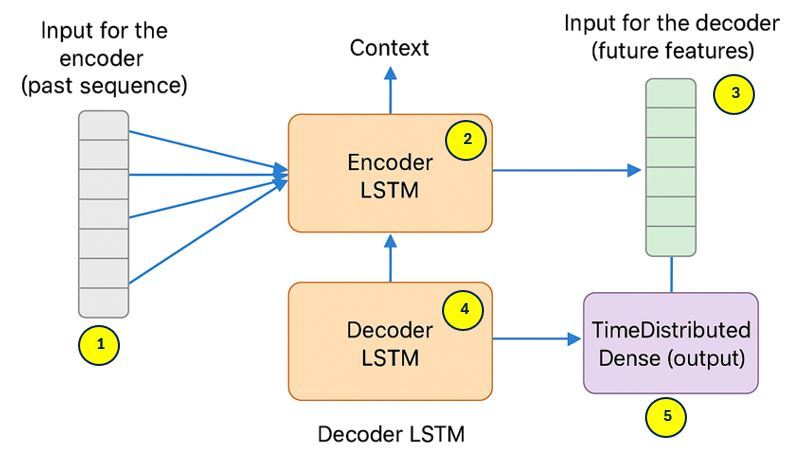

In [ ]:
# from IPython.display import Image
# Image("F:\\02. EMSFS\\12 - AI\\Corsi AI\\Sezione 16 - Addestramento di una rete neurale\\Esempi Programmi\\Architettura LSTM SEq2Seq.JPG")

### Importa Librerie

In [2]:
# <cell 3>
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
import os
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, TimeDistributed
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from pathlib import Path
import logging
from datetime import datetime as dt
import json

### Parametri generali

In [3]:
# <cell 5>
# Parametri temporali e di finestra
HISTORICAL_MONTHS = 6               # Periodo tipico che permette di osservare pattern stagionali e variazioni settimanali
FREQ = 'h'                          # Si usa la frequenza oraria perché è standard nei modelli di consumo e produzione elettrica
FUTURE_DAYS = 7                     # La previsione su una settimana è bilanciata tra accuratezza e utilità operativa       
PAST_WINDOW = 168                   # 7 giorni di dati storici (24 ore x 7gg) per fornire abbastanza contesto al modello
FUTURE_WINDOW = 168                 # 	Previsione completa per i prossimi 7 giorni	(24 ore x 7gg)

# Suddivisione dataset 
TEST_RATIO = 0.15                           # 15% è una quota comune per test finale
VAL_RATIO = 0.15                            # 15% Valido per tuning e controllo overfitting 
TRAIN_RATIO = 1 - TEST_RATIO - VAL_RATIO    # Derivata automaticamente (1 - test - val)

# Parametri fisici per produzione FV
PANEL_CAPACITY = 5.0                        # Tipica potenza di un impianto fotovoltaico residenziale
EFFICIENCY = 0.18                           # Coefficiente realistico per impianti moderni (moduli + inverter)

# Parametri di consumo energetico
BASE_CONSUMPTION = 1.5                      # Consumo medio continuo residenziale su base oraria in Kwh
TEMP_EFFECT_FACTOR = 0.05                   # Valore empirico che simula l’influenza di riscaldamento/raffrescamento su base °C

### Funzioni per generazione dati sintetici 

#### Genera_date_range_storico

In [4]:
# <cell 8>
# Funzioni per generazione dati sintetici 
def genera_date_range_storico(months=HISTORICAL_MONTHS, freq=FREQ, tz=None):
    """Restituisce un DatetimeIndex orario di ultimi 'months' mesi fino a ora."""
    end = pd.Timestamp.now(tz='Europe/Rome').floor('h')
    start = end - pd.DateOffset(months=months)
    return pd.date_range(start=start, end=end, freq=freq)

#### Genera_meteo_sintetico (temperature (°C), irradiance (0-1), wind_speed (m/s).)

In [5]:
# <cell 10>
def genera_meteo_sintetico(index):
# Modifica Codex: Aggiunta controllo per assicurarsi che l'indice sia un DatetimeIndex
    if not isinstance(index, pd.DatetimeIndex):
        raise ValueError("L'indice deve essere un DatetimeIndex.")
# Modifica Codex: fine  
    rng = index                                                 
    n = len(rng)
    
# Simulazione temperatura: pattern giornaliero + stagionale
    hours = np.arange(n)                                        # array da 0 a n-1 (serve solo se vuoi un contatore lineare — qui però non viene poi usato)
                                                    
    daily = 10 * np.sin(2 * np.pi * (rng.hour / 24))           
    day_of_year = rng.dayofyear.values
    seasonal = 15 * np.sin(2 * np.pi * (day_of_year / 365))     
    temp = 20 + daily + seasonal + np.random.normal(0, 2, n)    
    hour_angle = (rng.hour - 6) / 12                            
    irradiance = np.clip(np.sin(np.pi * (rng.hour / 24)), 0, None)
    irradiance = irradiance + np.random.normal(0, 0.05, n)      
    irradiance = np.clip(irradiance, 0, 1)                     
    wind = 3 + np.random.normal(0, 1, n)                        
    wind = np.clip(wind, 0, None)                             
    df = pd.DataFrame({'temperature': temp, 'irradiance': irradiance, 'wind_speed': wind}, index=rng)  
    return df

#### Genera_consumo_sintetico

In [6]:
# <cell 12>
def genera_consumo_sintetico(index, meteo_df):
    """Genera consumi orari basati su pattern giornaliero e correlazione con temperatura."""
    rng = index
    n = len(rng)
    # Pattern giornaliero: più alto nelle fasce mattina e sera
    hour = rng.hour.values
    daily_pattern = 0.5 + 0.5 * (np.sin(2 * np.pi * (hour - 8) / 24) * 0.5 + 0.5)
    # Base consumo
    consumo = BASE_CONSUMPTION * daily_pattern
    # Effetto temperatura: se temp >22 o <16 aumenta consumo
    temp = meteo_df['temperature'].values
    temp_effect = TEMP_EFFECT_FACTOR * np.maximum(0, np.abs(temp - 20) - 2)
    consumo = consumo + temp_effect
    consumo = consumo + np.random.normal(0, 0.2, n)
    consumo = np.clip(consumo, 0, None)
    return pd.Series(consumo, index=rng, name='consumption')

#### Genera_produzione_sintetica

In [7]:
# <cell 14>
def genera_produzione_sintetica(index, meteo_df):
    """Genera produzione FV oraria basata su irradiance e capacità."""
    irr = meteo_df['irradiance'].values
    # Produzione in kW: capacity * efficienza * irradiance
    prod = PANEL_CAPACITY * EFFICIENCY * irr
    prod = prod + np.random.normal(0, 0.1, len(irr))
    prod = np.clip(prod, 0, None)
    return pd.Series(prod, index=index, name='production')

### Pulizia e preprocessing

In [8]:
# <cell 16>
def pulisci_e_imputa(df):
# Modifica Codex: Aggiunta controllo per assicurarsi che l'indice sia un DatetimeIndex
    if not isinstance(df.index, pd.DatetimeIndex):
        raise ValueError("L'indice deve essere un DatetimeIndex per l'interpolazione temporale.")
# fine modifica Codex
    df_clean = df.copy()
    # Introduciamo missing casuali (1% dei valori)
    mask = np.random.rand(len(df_clean)) < 0.01
    df_clean.loc[df_clean.index[mask], df_clean.columns] = np.nan
    # Imputazione: interpolazione lineare
    df_clean = df_clean.interpolate(method='time')
    df_clean = df_clean.ffill().bfill()
    return df_clean

### Suddivisione in Train/Val/Test

In [9]:
# <cell 18>
def split_time_series(df, train_ratio=TRAIN_RATIO, val_ratio=VAL_RATIO, past_window=PAST_WINDOW):
    n = len(df)
    idx_train_end = int(n * train_ratio)
    idx_val_end = int(n * (train_ratio + val_ratio))
    train_buffer = min(past_window, idx_train_end)  # Limita il buffer alla dimensione del training set
    df_train = df.iloc[:idx_train_end]
    val_start_with_buffer = max(0, idx_train_end - train_buffer)
    df_val = df.iloc[val_start_with_buffer:idx_val_end]
    test_start_with_buffer = max(0, idx_val_end - train_buffer)
    df_test = df.iloc[test_start_with_buffer:]
    return df_train, df_val, df_test

### Analisi statistica

In [10]:
# <cell 20>
def analisi_statistica(df, title_prefix=""):
    """Stampa statistiche descrittive e produce grafici base."""
    print(f"Statistiche descrittive {title_prefix}:")
    display = df.describe()
    print(display)
    # Grafico delle serie
    df.plot(subplots=True, figsize=(12, 8), title=title_prefix)
    plt.tight_layout()
    plt.show()
    # Correlazione tra variabili
    corr = df.corr()
    print(f"Matrice di correlazione {title_prefix}:")
    print(corr)
    plt.figure(figsize=(6, 5))
    plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
    plt.colorbar()
    plt.xticks(range(len(corr)), corr.columns, rotation=45)
    plt.yticks(range(len(corr)), corr.columns)
    plt.title(f"Correlazione {title_prefix}")
    plt.tight_layout()
    plt.show()

### Preparazione sequenze per LSTM seq2seq

In [11]:
# <cell 22>
def crea_sequence_dataset(df_features_past, df_targets_past, df_features_future, df_targets_future, past_window=PAST_WINDOW, future_window=FUTURE_WINDOW):
   
    X_enc_list, X_dec_list, y_list = [], [], []
    total_len = len(df_features_past)
    for i in range(total_len - past_window - future_window + 1):
        enc_slice = df_features_past.iloc[i:i+past_window].values
        # (opzionale) includere target passato nell'encoder. Qui assumiamo df_features_past già contiene tutto.
        dec_features = df_features_future.iloc[i+past_window:i+past_window+future_window].values
        y_slice = df_targets_future.iloc[i+past_window:i+past_window+future_window].values
        X_enc_list.append(enc_slice)
        X_dec_list.append(dec_features)
        y_list.append(y_slice)
    X_enc = np.array(X_enc_list)
    X_dec = np.array(X_dec_list)
    y = np.array(y_list)
    return X_enc, X_dec, y

### Definizione modello Sequence-to-Sequence (Seq2Seq) in Keras

In [12]:
# <cell 24>
def build_seq2seq_model(n_features_enc, n_features_dec, latent_dim=64, future_window=24, dropout_rate=0.3):
    # Encoder
    encoder_inputs = Input(shape=(None, n_features_enc), name='encoder_inputs')
    encoder_lstm = LSTM(latent_dim, return_state=True, name='encoder_lstm')
    _, state_h, state_c = encoder_lstm(encoder_inputs)
    
    # Dropout su stati encoder (regolarizzazione indiretta)
    state_h = Dropout(dropout_rate, name='dropout_state_h')(state_h)
    state_c = Dropout(dropout_rate, name='dropout_state_c')(state_c)
    encoder_states = [state_h, state_c]

    # Decoder
    decoder_inputs = Input(shape=(None, n_features_dec), name='decoder_inputs')
    decoder_lstm = LSTM(latent_dim, return_sequences=True, return_state=True, name='decoder_lstm')
    decoder_outputs, _, _ = decoder_lstm(decoder_inputs, initial_state=encoder_states)

    # Dropout su output del decoder
    decoder_outputs = Dropout(dropout_rate, name='dropout_decoder_output')(decoder_outputs)

    # Output time-distributed
    decoder_dense = TimeDistributed(Dense(1), name='decoder_dense')
    decoder_outputs = decoder_dense(decoder_outputs)

    # Modello finale
    model = Model([encoder_inputs, decoder_inputs], decoder_outputs)
    model.compile(optimizer='adam', loss='mse')

    return model

### Metriche

In [13]:
# <cell 26>
#OLD-COD-INI
# def valuta_metriche(y_true, y_pred):
#     mae = mean_absolute_error(y_true.flatten(), y_pred.flatten())
#     rmse = np.sqrt(mean_squared_error(y_true.flatten(), y_pred.flatten()))
#     return mae, rmse
#OLD-COD-FIN

#NEW-COD-INI
def fit_transform_target_scaler(train_series, val_series, test_series, target_name="target"):
    """Gestisce lo scaling del target evitando data leakage.

    Fit dello scaler esclusivamente sul training set, poi transform coerente
    su training, validation e test mantenendo una separazione esplicita tra
    scala originale e scala normalizzata.
    """
    scaler = StandardScaler()

    train_arr = train_series.values.reshape(-1, 1)
    val_arr = val_series.values.reshape(-1, 1)
    test_arr = test_series.values.reshape(-1, 1)

    scaler.fit(train_arr)

    train_scaled = pd.Series(scaler.transform(train_arr).flatten(), index=train_series.index, name=train_series.name)
    val_scaled = pd.Series(scaler.transform(val_arr).flatten(), index=val_series.index, name=val_series.name)
    test_scaled = pd.Series(scaler.transform(test_arr).flatten(), index=test_series.index, name=test_series.name)

    reconstructed_train = scaler.inverse_transform(train_scaled.values.reshape(-1, 1)).flatten()
    if not np.allclose(reconstructed_train, train_series.values, atol=1e-6):
        raise ValueError(f"Incoerenza nello scaling del target {target_name}: inverse_transform non ricostruisce il training set.")

    print(f"✅ Target scaler '{target_name}' fittato solo su TRAIN: n_train={len(train_series)}, n_val={len(val_series)}, n_test={len(test_series)}")
    return {'scaler': scaler, 'train_scaled': train_scaled, 'val_scaled': val_scaled, 'test_scaled': test_scaled}


def inverse_transform_array(values, scaler, expected_ndim=None):
    """Riporta array 2D/3D nella scala originale preservando la shape."""
    values = np.asarray(values)
    original_shape = values.shape
    if expected_ndim is not None and values.ndim != expected_ndim:
        raise ValueError(f"Array con ndim={values.ndim}, atteso ndim={expected_ndim}.")
    return scaler.inverse_transform(values.reshape(-1, 1)).reshape(original_shape)


def calcola_metriche_original_scale(y_true_scaled, y_pred_scaled, scaler, dataset_name="", target_name=""):
    """Calcola MAE/RMSE esclusivamente nella scala fisica originale."""
    y_true_scaled = np.asarray(y_true_scaled)
    y_pred_scaled = np.asarray(y_pred_scaled)

    if y_true_scaled.shape != y_pred_scaled.shape:
        raise ValueError(
            f"Shape incoerenti per {target_name} su {dataset_name}: "
            f"y_true={y_true_scaled.shape}, y_pred={y_pred_scaled.shape}"
        )

    y_true_original = inverse_transform_array(y_true_scaled, scaler)
    y_pred_original = inverse_transform_array(y_pred_scaled, scaler)

    mae = mean_absolute_error(y_true_original.flatten(), y_pred_original.flatten())
    rmse = np.sqrt(mean_squared_error(y_true_original.flatten(), y_pred_original.flatten()))

    print(f"📏 Metriche {target_name} - {dataset_name} calcolate in scala originale: MAE={mae:.4f}, RMSE={rmse:.4f}")
    return {'mae': mae, 'rmse': rmse, 'y_true_original': y_true_original, 'y_pred_original': y_pred_original}
#NEW-COD-FIN

###  1. Generazione dataset storico sintetico

In [14]:
# <cell 29>
# 1. Generazione dataset storico sintetico
print("Generazione dataset storico sintetico...")
idx_hist = genera_date_range_storico()
# # print (idx_hist)
# print(idx_hist[:5])
# print("-------------------------------")
# print(idx_hist[-5:])
print("idx_hist: da", idx_hist[0], "a", idx_hist[-1])

Generazione dataset storico sintetico...
idx_hist: da 2025-10-09 11:00:00+02:00 a 2026-04-09 11:00:00+02:00


#### Generazione date nel periodo storico del Meteo

In [15]:
# <cell 31>
meteo_hist = genera_meteo_sintetico(idx_hist)
meteo_hist = pulisci_e_imputa(meteo_hist)
print("Generazione dataset meteo...")
print(meteo_hist[:5])
print("-------------------------------")
print(meteo_hist[-5:])

Generazione dataset meteo...
                           temperature  irradiance  wind_speed
2025-10-09 11:00:00+02:00     6.380760    0.914469    3.610145
2025-10-09 12:00:00+02:00     4.421082    0.963541    1.116922
2025-10-09 13:00:00+02:00     6.221056    1.000000    1.438759
2025-10-09 14:00:00+02:00    -2.324765    0.962111    5.183900
2025-10-09 15:00:00+02:00     0.621915    0.938577    2.184283
-------------------------------
                           temperature  irradiance  wind_speed
2026-04-09 07:00:00+02:00    44.441116    0.738721    1.679604
2026-04-09 08:00:00+02:00    45.057950    0.968012    4.424451
2026-04-09 09:00:00+02:00    41.653731    0.954837    1.943932
2026-04-09 10:00:00+02:00    42.299401    0.979084    3.260825
2026-04-09 11:00:00+02:00    32.951200    1.000000    2.464033


#### Generazione Consumo sintetico nel periodo di riferimento

In [16]:
# <cell 33>
from pathlib import Path
# data_dir = Path('data') / 'energia'
data_dir = Path().resolve() / "data"

data_dir.mkdir(parents=True, exist_ok=True)

use_csv_consumi = input("Vuoi usare un file CSV esterno per i consumi? (s/n): ").strip().lower() == 's'
if use_csv_consumi:
    print("📂 Caricamento consumi da CSV...")
    csv_path = data_dir / "consumo_storico.csv"
    consumo_hist = pd.read_csv(csv_path, index_col=0, parse_dates=True)
else:
    print("⚙️ Generazione sintetica dei consumi...")
    consumo_hist = genera_consumo_sintetico(idx_hist, meteo_hist)
    consumo_hist.to_csv(data_dir / "consumo_storico.csv")
    print(f"💾 File 'consumo_storico.csv' salvato in: {(data_dir / 'consumo_storico.csv').resolve()}")

print("Generazione dataset Consumo...")
print(consumo_hist[:5])
print("-------------------------------")
print(consumo_hist[-5:])

⚙️ Generazione sintetica dei consumi...
💾 File 'consumo_storico.csv' salvato in: F:\05. WEBEUT\99 - Story\22. Linkedin 2024\Articoli\01 - AI Generiche\35. OpenAI Prism\data\consumo_storico.csv
Generazione dataset Consumo...
2025-10-09 11:00:00+02:00    2.103199
2025-10-09 12:00:00+02:00    2.005372
2025-10-09 13:00:00+02:00    2.205845
2025-10-09 14:00:00+02:00    2.412892
2025-10-09 15:00:00+02:00    2.370612
Freq: h, Name: consumption, dtype: float64
-------------------------------
2026-04-09 07:00:00+02:00    2.116002
2026-04-09 08:00:00+02:00    2.196140
2026-04-09 09:00:00+02:00    2.398135
2026-04-09 10:00:00+02:00    2.519813
2026-04-09 11:00:00+02:00    2.225430
Freq: h, Name: consumption, dtype: float64


#### Generazione Produzione sintetica nel periodo di riferimento

In [17]:
# <cell 35>
use_csv_produzione = input("Vuoi usare un file CSV esterno per la produzione FV? (s/n): ").strip().lower() == 's'
data_dir = Path().resolve() / "data"
data_dir.mkdir(parents=True, exist_ok=True)

if use_csv_produzione:
    print("📂 Caricamento produzione FV da CSV...")
    produzione_hist = pd.read_csv(data_dir / "produzione_storico.csv", index_col=0, parse_dates=True)
else:
    print("⚙️ Generazione sintetica produzione FV...")
    produzione_hist = genera_produzione_sintetica(idx_hist, meteo_hist)
    produzione_hist.to_csv(data_dir / "produzione_storico.csv")
    print(f"💾 File 'produzione_storico.csv' salvato in: {(data_dir / 'produzione_storico.csv').resolve()}")

print(produzione_hist[:5])
print("-------------------------------")
print(produzione_hist[-5:])

⚙️ Generazione sintetica produzione FV...
💾 File 'produzione_storico.csv' salvato in: F:\05. WEBEUT\99 - Story\22. Linkedin 2024\Articoli\01 - AI Generiche\35. OpenAI Prism\data\produzione_storico.csv
2025-10-09 11:00:00+02:00    0.865349
2025-10-09 12:00:00+02:00    0.891837
2025-10-09 13:00:00+02:00    0.852101
2025-10-09 14:00:00+02:00    1.047269
2025-10-09 15:00:00+02:00    0.836289
Freq: h, Name: production, dtype: float64
-------------------------------
2026-04-09 07:00:00+02:00    0.602184
2026-04-09 08:00:00+02:00    0.976916
2026-04-09 09:00:00+02:00    0.770946
2026-04-09 10:00:00+02:00    0.967836
2026-04-09 11:00:00+02:00    1.142828
Freq: h, Name: production, dtype: float64


#### Creazione del Dataset Concatenato (Data, Tempetarura, Irradiazione, Wind, Consumo e Produzione)

In [18]:
# <cell 37>
df_hist = pd.concat([meteo_hist, consumo_hist, produzione_hist], axis=1)
# print (df_hist)
print(df_hist[:5])
print("-------------------------------")
print(df_hist[-5:])

                           temperature  irradiance  wind_speed  consumption  \
2025-10-09 11:00:00+02:00     6.380760    0.914469    3.610145     2.103199   
2025-10-09 12:00:00+02:00     4.421082    0.963541    1.116922     2.005372   
2025-10-09 13:00:00+02:00     6.221056    1.000000    1.438759     2.205845   
2025-10-09 14:00:00+02:00    -2.324765    0.962111    5.183900     2.412892   
2025-10-09 15:00:00+02:00     0.621915    0.938577    2.184283     2.370612   

                           production  
2025-10-09 11:00:00+02:00    0.865349  
2025-10-09 12:00:00+02:00    0.891837  
2025-10-09 13:00:00+02:00    0.852101  
2025-10-09 14:00:00+02:00    1.047269  
2025-10-09 15:00:00+02:00    0.836289  
-------------------------------
                           temperature  irradiance  wind_speed  consumption  \
2026-04-09 07:00:00+02:00    44.441116    0.738721    1.679604     2.116002   
2026-04-09 08:00:00+02:00    45.057950    0.968012    4.424451     2.196140   
2026-04-09 09:00

### 2. Dataset previsioni meteo per i prossimi 7 giorni

In [19]:
# <cell 39>
# 2. Dataset previsioni meteo per i prossimi 7 giorni
print("Generazione previsioni meteo sintetiche per i prossimi 7 giorni...")
last_date = idx_hist[-1]
idx_future = pd.date_range(start=last_date + pd.Timedelta(hours=1), periods=FUTURE_DAYS*24, freq='h', tz='Europe/Rome')
meteo_future = genera_meteo_sintetico(idx_future)
meteo_future = pulisci_e_imputa(meteo_future)
print(meteo_future[:5])
print("-------------------------------")
print(meteo_future[-5:])

Generazione previsioni meteo sintetiche per i prossimi 7 giorni...
                           temperature  irradiance  wind_speed
2026-04-09 12:00:00+02:00    34.665170    1.000000    3.304940
2026-04-09 13:00:00+02:00    33.555895    0.904408    2.433284
2026-04-09 14:00:00+02:00    31.907735    0.872300    2.415773
2026-04-09 15:00:00+02:00    29.351142    0.880236    2.993011
2026-04-09 16:00:00+02:00    24.322622    0.921695    2.370971
-------------------------------
                           temperature  irradiance  wind_speed
2026-04-16 07:00:00+02:00    44.011571    0.839008    5.314237
2026-04-16 08:00:00+02:00    43.651087    0.908147    3.686106
2026-04-16 09:00:00+02:00    43.201280    0.932428    2.994380
2026-04-16 10:00:00+02:00    41.607376    0.955563    2.555397
2026-04-16 11:00:00+02:00    34.851568    1.000000    3.629044


### 3. Split train/val/test (solo storico)

In [20]:
# <cell 41>
# 3. Split train/val/test (solo storico)
df_train, df_val, df_test = split_time_series(df_hist)
print("Lunghezza dataset : ", len(df_hist))
print("Lunghezza Train : ", len(df_train))
print("Lunghezza Val : ", len(df_val))
print("Lunghezza Test : ", len(df_test))
print("---------------------------------------")
print("Suddivisione in train/val/test...")
print("TRAIN: da", df_train.index[0], "a", df_train.index[-1])
print("VAL: da", df_val.index[0], "a", df_val.index[-1])
print("TEST: da", df_test.index[0], "a", df_test.index[-1])

Lunghezza dataset :  4369
Lunghezza Train :  3058
Lunghezza Val :  823
Lunghezza Test :  824
---------------------------------------
Suddivisione in train/val/test...
TRAIN: da 2025-10-09 11:00:00+02:00 a 2026-02-13 19:00:00+01:00
VAL: da 2026-02-06 20:00:00+01:00 a 2026-03-13 02:00:00+01:00
TEST: da 2026-03-06 03:00:00+01:00 a 2026-04-09 11:00:00+02:00


### 4. Analisi statistica

#### 4.1 Analisi statistica TRAIN

Analisi statistica TRAIN...
Statistiche descrittive TRAIN:
       temperature   irradiance   wind_speed  consumption   production
count  3058.000000  3058.000000  3058.000000  3058.000000  3058.000000
mean     16.025955     0.633069     3.009754     1.505941     0.572900
std      10.925960     0.308188     1.016670     0.497470     0.290345
min      -8.562666     0.000000     0.000000     0.239201     0.000000
25%       7.774466     0.379030     2.325994     1.143036     0.335412
50%      15.898661     0.702480     3.002161     1.470583     0.625430
75%      23.666558     0.914612     3.692060     1.849346     0.811367
max      42.971673     1.000000     6.608661     2.996785     1.203180


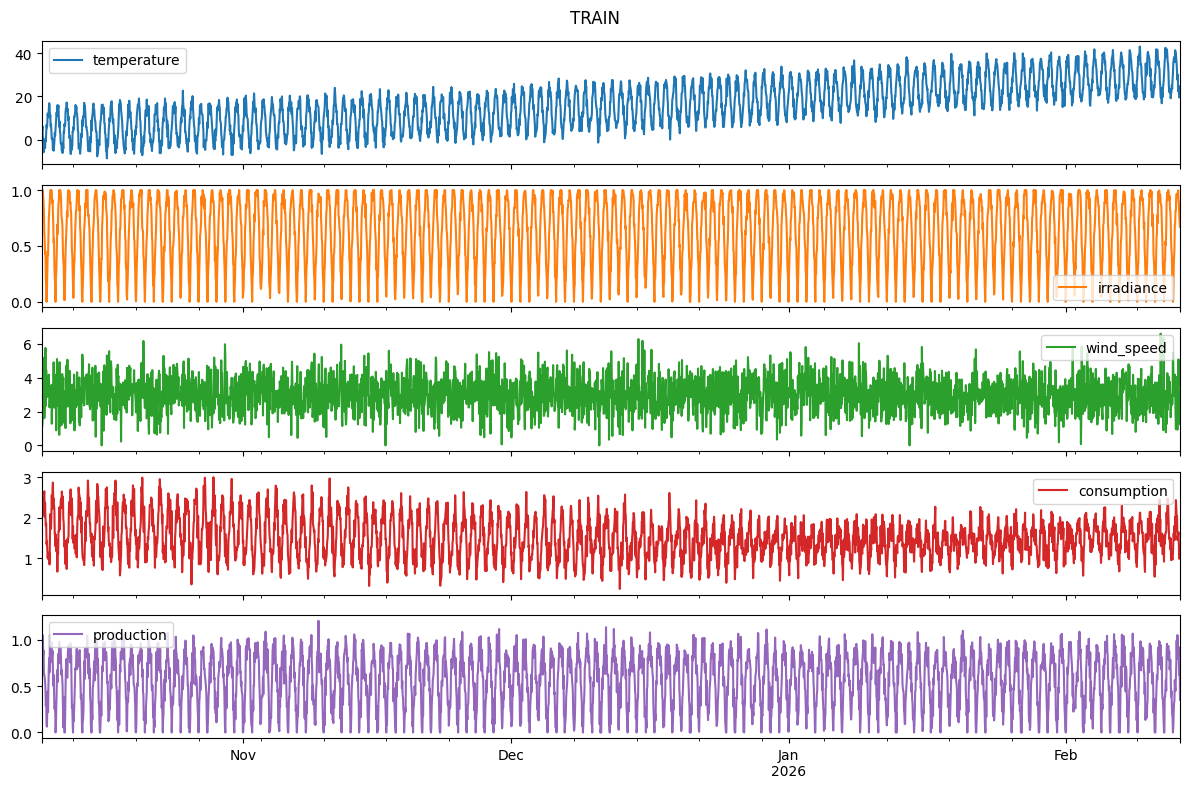

Matrice di correlazione TRAIN:
             temperature  irradiance  wind_speed  consumption  production
temperature     1.000000    0.000094    0.001591    -0.463087    0.004959
irradiance      0.000094    1.000000   -0.022428     0.469710    0.943644
wind_speed      0.001591   -0.022428    1.000000    -0.009966   -0.015489
consumption    -0.463087    0.469710   -0.009966     1.000000    0.446670
production      0.004959    0.943644   -0.015489     0.446670    1.000000


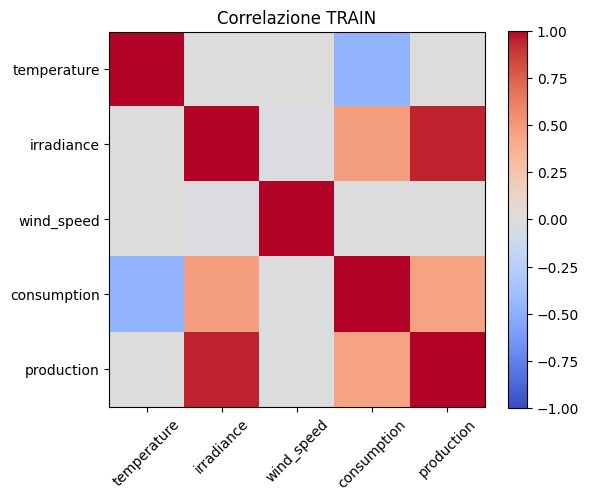

In [21]:
# <cell 44>
# 4. Analisi statistica
print("Analisi statistica TRAIN...")
analisi_statistica(df_train, title_prefix="TRAIN")

#### 4.2 Analisi statistica VAL

Analisi statistica VAL...
Statistiche descrittive VAL:
       temperature  irradiance  wind_speed  consumption  production
count   823.000000  823.000000  823.000000   823.000000  823.000000
mean     31.986296    0.633214    2.979542     1.632867    0.569207
std       7.452523    0.310408    1.020329     0.395891    0.296268
min      16.831172    0.000000    0.000000     0.540939    0.000000
25%      25.189951    0.377731    2.297824     1.345810    0.337381
50%      32.155418    0.707364    2.963230     1.617116    0.632210
75%      38.729710    0.921050    3.695694     1.924031    0.815115
max      48.301046    1.000000    6.608661     2.604356    1.161646


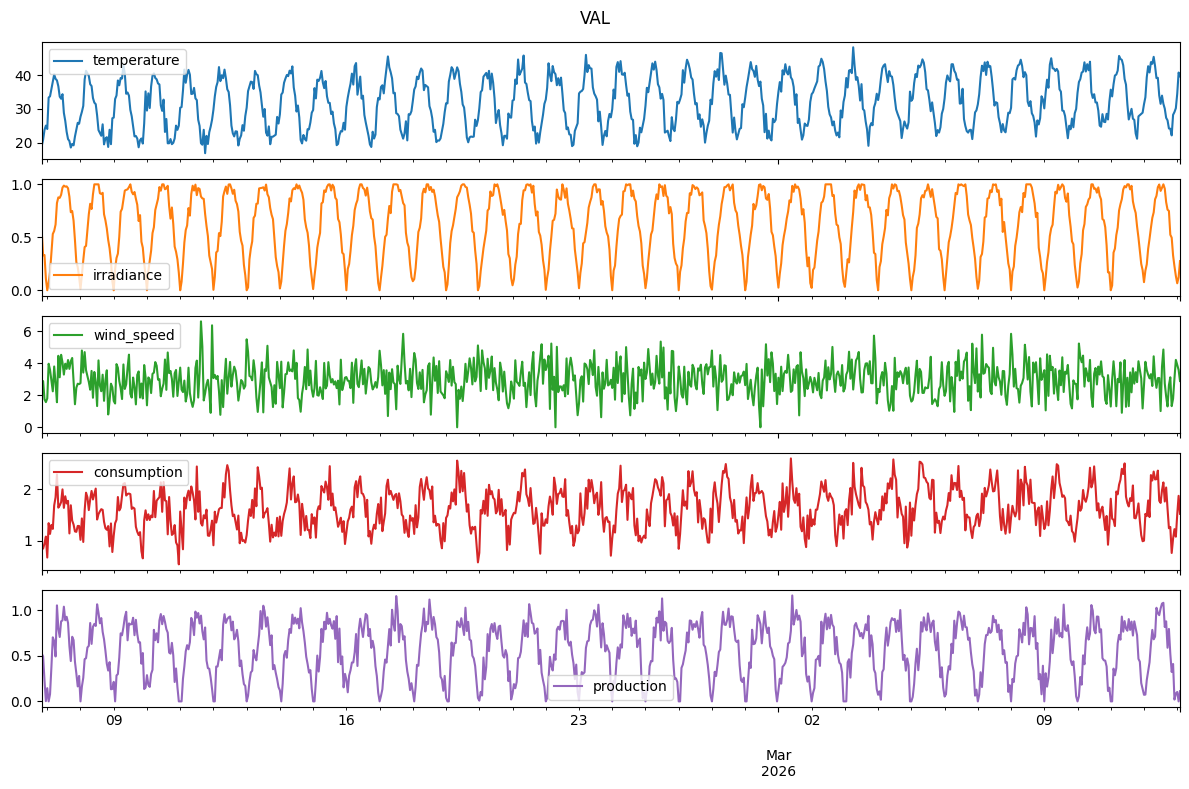

Matrice di correlazione VAL:
             temperature  irradiance  wind_speed  consumption  production
temperature     1.000000    0.013155    0.020785     0.622056    0.009604
irradiance      0.013155    1.000000   -0.003310     0.558000    0.943373
wind_speed      0.020785   -0.003310    1.000000    -0.000764   -0.012258
consumption     0.622056    0.558000   -0.000764     1.000000    0.525239
production      0.009604    0.943373   -0.012258     0.525239    1.000000


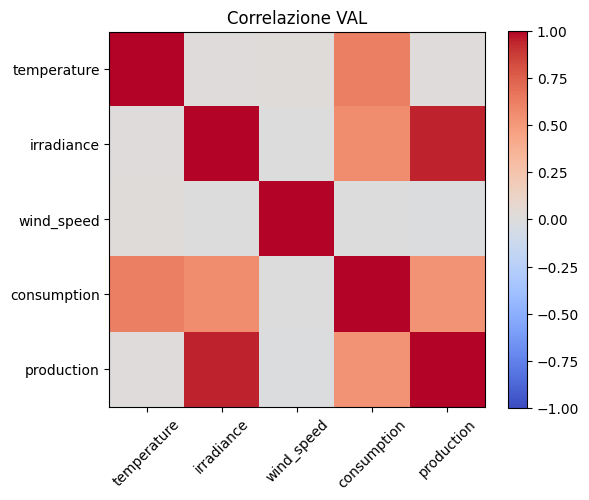

In [22]:
# <cell 46>
print("Analisi statistica VAL...")
analisi_statistica(df_val, title_prefix="VAL")

#### 4.3 Analisi statistica TEST

Analisi statistica TEST...
Statistiche descrittive TEST:
       temperature  irradiance  wind_speed  consumption  production
count   824.000000  824.000000  824.000000   824.000000  824.000000
mean     34.674756    0.637777    3.047746     1.773539    0.574512
std       7.331321    0.309698    0.981456     0.382351    0.291807
min      21.029590    0.000000    0.000000     0.762411    0.000000
25%      28.074033    0.383415    2.393691     1.477436    0.348725
50%      34.720499    0.706531    3.022211     1.780151    0.628336
75%      41.345353    0.919022    3.705391     2.072448    0.814433
max      49.808428    1.000000    6.466253     2.935958    1.142828


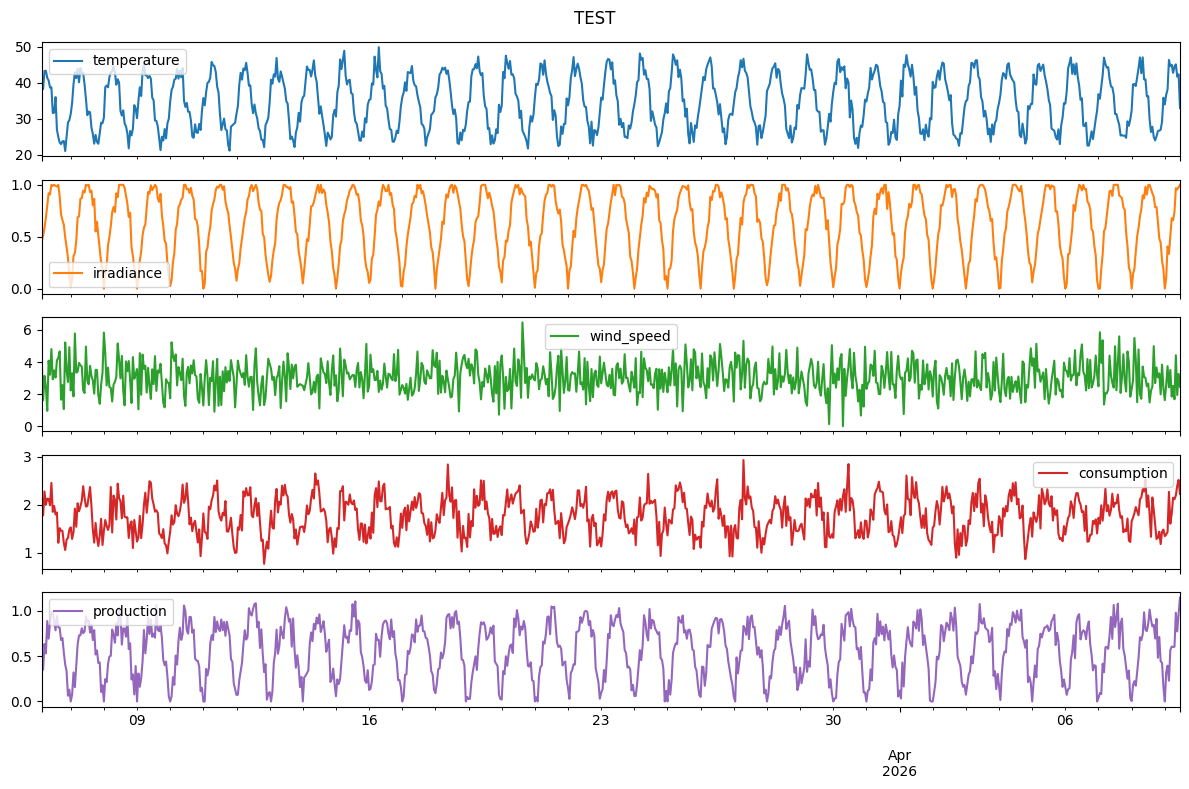

Matrice di correlazione TEST:
             temperature  irradiance  wind_speed  consumption  production
temperature     1.000000   -0.017036    0.031326     0.604392   -0.009970
irradiance     -0.017036    1.000000   -0.005045     0.555701    0.941996
wind_speed      0.031326   -0.005045    1.000000     0.033366   -0.030567
consumption     0.604392    0.555701    0.033366     1.000000    0.531373
production     -0.009970    0.941996   -0.030567     0.531373    1.000000


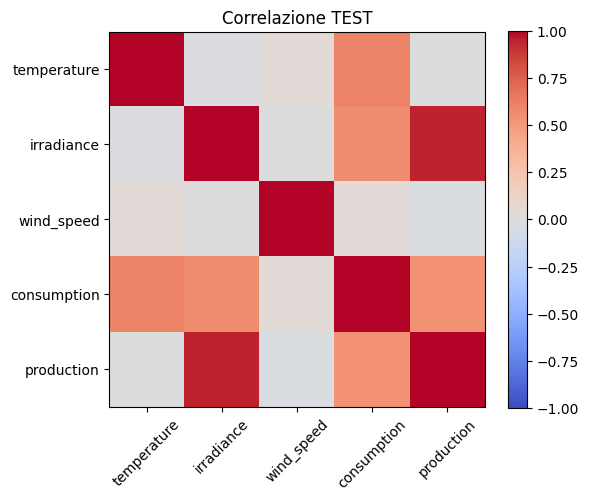

In [23]:
# <cell 48>
print("Analisi statistica TEST...")
analisi_statistica(df_test, title_prefix="TEST")

### 5. Preparazione dati per i modelli di Produzione e Consumo

In [25]:
# <cell 50>
# 5. Preparazione dati per modello Produzione e Consumo (con scaling e senza data leakage)
print("Preparazione dati per modelli (scaling, split coerente)...")

#OLD-COD-INI
#
# Features encoder per produzione e consumo
# df_features_past_prod = pd.concat([df_hist[['temperature', 'irradiance', 'wind_speed']], df_hist[['production']]], axis=1)
# df_features_past_cons = pd.concat([df_hist[['temperature', 'irradiance', 'wind_speed']], df_hist[['consumption']]], axis=1)

# # Metoo storico separato per train/val/test (SOLO storico, senza meteo_future)
# meteo_train = meteo_hist.loc[df_train.index]
# meteo_val = meteo_hist.loc[df_val.index]
# meteo_test = meteo_hist.loc[df_test.index]

# # Evitare data leakage: costruire subset di target per ogni fold
# df_targets_prod_train = produzione_hist.loc[df_train.index]
# df_targets_prod_val = produzione_hist.loc[df_val.index]
# df_targets_prod_test = produzione_hist.loc[df_test.index]

# df_targets_cons_train = consumo_hist.loc[df_train.index]
# df_targets_cons_val = consumo_hist.loc[df_val.index]
# df_targets_cons_test = consumo_hist.loc[df_test.index]

# # Normalizzazione: fit SOLO su dati di train
# scaler_features_prod = StandardScaler()
# scaler_features_cons = StandardScaler()
# scaler_prod_target = StandardScaler()
# scaler_cons_target = StandardScaler()

# scaler_features_prod.fit(df_features_past_prod.loc[df_train.index].values)
# scaler_features_cons.fit(df_features_past_cons.loc[df_train.index].values)
# scaler_prod_target.fit(df_targets_prod_train.values.reshape(-1, 1))
# scaler_cons_target.fit(df_targets_cons_train.values.reshape(-1, 1))

# # Applicare scaling (transform) alle serie mantenendo indici/colonne
# df_features_past_prod_scaled = pd.DataFrame(scaler_features_prod.transform(df_features_past_prod.values), index=df_features_past_prod.index, columns=df_features_past_prod.columns)
# df_features_past_cons_scaled = pd.DataFrame(scaler_features_cons.transform(df_features_past_cons.values), index=df_features_past_cons.index, columns=df_features_past_cons.columns)

# produzione_hist_scaled = pd.Series(scaler_prod_target.transform(produzione_hist.values.reshape(-1,1)).flatten(), index=produzione_hist.index, name='production')
# consumo_hist_scaled = pd.Series(scaler_cons_target.transform(consumo_hist.values.reshape(-1,1)).flatten(), index=consumo_hist.index, name='consumption')

# # Preparare meteo storico scalato (usiamo gli stessi scaler_features e ricostruiamo solo le colonne meteo)
# meteo_hist_arr_for_prod = df_hist[['temperature','irradiance','wind_speed','production']].values
# meteo_hist_scaled_prod = pd.DataFrame(scaler_features_prod.transform(meteo_hist_arr_for_prod)[:, :3], index=df_hist.index, columns=['temperature','irradiance','wind_speed'])
# meteo_hist_arr_for_cons = df_hist[['temperature','irradiance','wind_speed','consumption']].values
# meteo_hist_scaled_cons = pd.DataFrame(scaler_features_cons.transform(meteo_hist_arr_for_cons)[:, :3], index=df_hist.index, columns=['temperature','irradiance','wind_speed'])

# meteo_train_scaled_prod = meteo_hist_scaled_prod.loc[meteo_train.index]
# meteo_val_scaled_prod = meteo_hist_scaled_prod.loc[meteo_val.index]
# meteo_test_scaled_prod = meteo_hist_scaled_prod.loc[meteo_test.index]

# meteo_train_scaled_cons = meteo_hist_scaled_cons.loc[meteo_train.index]
# meteo_val_scaled_cons = meteo_hist_scaled_cons.loc[meteo_val.index]
# meteo_test_scaled_cons = meteo_hist_scaled_cons.loc[meteo_test.index]

# # Creazione sequence dataset - Consumo (train/val/test) usando solo dati coerenti per ciascun fold
# X_enc_train_c, X_dec_train_c, y_train_c = crea_sequence_dataset(
#     df_features_past_cons_scaled.loc[df_train.index],
#     df_train[['consumption']],
#     meteo_train_scaled_cons,
#     consumo_hist_scaled,
#     past_window=PAST_WINDOW,
#     future_window=FUTURE_WINDOW
# )
# X_enc_val_c, X_dec_val_c, y_val_c = crea_sequence_dataset(
#     df_features_past_cons_scaled.loc[df_val.index],
#     df_val[['consumption']],
#     meteo_val_scaled_cons,
#     df_targets_cons_val,
#     past_window=PAST_WINDOW,
#     future_window=FUTURE_WINDOW
# )
# X_enc_test_c, X_dec_test_c, y_test_c = crea_sequence_dataset(
#     df_features_past_cons_scaled.loc[df_test.index],
#     df_test[['consumption']],
#     meteo_test_scaled_cons,
#     df_targets_cons_test,
#     past_window=PAST_WINDOW,
#     future_window=FUTURE_WINDOW
# )

# # Creazione sequence dataset - Produzione (train/val/test)
# X_enc_train_p, X_dec_train_p, y_train_p = crea_sequence_dataset(
#     df_features_past_prod_scaled.loc[df_train.index],
#     df_train[['production']],
#     meteo_train_scaled_prod,
#     produzione_hist_scaled,
#     past_window=PAST_WINDOW,
#     future_window=FUTURE_WINDOW
# )
# X_enc_val_p, X_dec_val_p, y_val_p = crea_sequence_dataset(
#     df_features_past_prod_scaled.loc[df_val.index],
#     df_val[['production']],
#     meteo_val_scaled_prod,
#     df_targets_prod_val,
#     past_window=PAST_WINDOW,
#     future_window=FUTURE_WINDOW
# )
# X_enc_test_p, X_dec_test_p, y_test_p = crea_sequence_dataset(
#     df_features_past_prod_scaled.loc[df_test.index],
#     df_test[['production']],
#     meteo_test_scaled_prod,
#     df_targets_prod_test,
#     past_window=PAST_WINDOW,
#     future_window=FUTURE_WINDOW
# )

# # Funzione di validazione shape
# def validate_shapes(X_enc, X_dec, y, expected_enc_features, expected_dec_features, expected_past_window=PAST_WINDOW, expected_future_window=FUTURE_WINDOW):
#     assert X_enc.ndim == 3, f"X_enc deve essere 3D, trovato {X_enc.ndim}D"
#     assert X_dec.ndim == 3, f"X_dec deve essere 3D, trovato {X_dec.ndim}D"
#     assert y.ndim in (2,3), f"y deve essere 2D/3D, trovato {y.ndim}D"
#     assert X_enc.shape[1] == expected_past_window, f"X_enc: expected window={expected_past_window}, got {X_enc.shape[1]}"
#     assert X_dec.shape[1] == expected_future_window, f"X_dec: expected window={expected_future_window}, got {X_dec.shape[1]}"
#     assert X_enc.shape[2] == expected_enc_features, f"X_enc: expected {expected_enc_features} features, got {X_enc.shape[2]}"
#     assert X_dec.shape[2] == expected_dec_features, f"X_dec: expected {expected_dec_features} features, got {X_dec.shape[2]}"
#     assert not np.isnan(X_enc).any(), "X_enc contiene NaN"
#     assert not np.isnan(X_dec).any(), "X_dec contiene NaN"
#     assert not np.isnan(y).any(), "y contiene NaN"
#     print(f"✅ Shape validation passed: X_enc={X_enc.shape}, X_dec={X_dec.shape}, y={y.shape}")

# # Eseguire le validazioni minime
# n_features_enc = df_features_past_cons_scaled.shape[1]
# n_features_dec = meteo_train_scaled_cons.shape[1]
# validate_shapes(X_enc_train_c, X_dec_train_c, y_train_c, n_features_enc, n_features_dec)
# n_features_enc_p = df_features_past_prod_scaled.shape[1]
# n_features_dec_p = meteo_train_scaled_prod.shape[1]
# validate_shapes(X_enc_train_p, X_dec_train_p, y_train_p, n_features_enc_p, n_features_dec_p)

# print("Preparazione completata.")
# OLD-COD-FIN
#-----
#
# NEW-COD-INI
#
# Refactoring: separiamo in modo esplicito dati originali e dati scalati.
# Nessuna informazione di validation/test viene usata nel fit di scaler o modello.

# Features encoder per produzione e consumo
df_features_past_prod = pd.concat([df_hist[['temperature', 'irradiance', 'wind_speed']], df_hist[['production']]], axis=1)
df_features_past_cons = pd.concat([df_hist[['temperature', 'irradiance', 'wind_speed']], df_hist[['consumption']]], axis=1)

# Meteo storico separato per train/val/test (solo storico, senza meteo_future)
meteo_train = meteo_hist.loc[df_train.index]
meteo_val = meteo_hist.loc[df_val.index]
meteo_test = meteo_hist.loc[df_test.index]

# Target originali per ciascun fold (scala fisica)
df_targets_prod_train = produzione_hist.loc[df_train.index]
df_targets_prod_val = produzione_hist.loc[df_val.index]
df_targets_prod_test = produzione_hist.loc[df_test.index]

df_targets_cons_train = consumo_hist.loc[df_train.index]
df_targets_cons_val = consumo_hist.loc[df_val.index]
df_targets_cons_test = consumo_hist.loc[df_test.index]

# Controlli espliciti anti-leakage sulle partizioni temporali
#mm
past_window=PAST_WINDOW
#mm
assert df_train.index.max() < df_val.index.max(), "Split temporale train/val non coerente"
assert df_val.index.max() <= df_test.index.max(), "Split temporale val/test non coerente"
assert len(set(df_train.index).intersection(set(df_val.index[past_window:]))) == 0, "Leakage potenziale tra train e val"
assert len(set(df_train.index).intersection(set(df_test.index[past_window:]))) == 0, "Leakage potenziale tra train e test"

# Scaling feature: fit solo su TRAIN
scaler_features_prod = StandardScaler()
scaler_features_cons = StandardScaler()
scaler_features_prod.fit(df_features_past_prod.loc[df_train.index].values)
scaler_features_cons.fit(df_features_past_cons.loc[df_train.index].values)

# Scaling target tramite funzione dedicata
prod_scaling = fit_transform_target_scaler(
    df_targets_prod_train,
    df_targets_prod_val,
    df_targets_prod_test,
    target_name='production'
)
cons_scaling = fit_transform_target_scaler(
    df_targets_cons_train,
    df_targets_cons_val,
    df_targets_cons_test,
    target_name='consumption'
)

scaler_prod_target = prod_scaling['scaler']
scaler_cons_target = cons_scaling['scaler']

df_targets_prod_train_scaled = prod_scaling['train_scaled']
df_targets_prod_val_scaled = prod_scaling['val_scaled']
df_targets_prod_test_scaled = prod_scaling['test_scaled']

df_targets_cons_train_scaled = cons_scaling['train_scaled']
df_targets_cons_val_scaled = cons_scaling['val_scaled']
df_targets_cons_test_scaled = cons_scaling['test_scaled']

# Serie storiche scalate complete solo per ispezione/forecast; lo scaler resta sempre fit su TRAIN
produzione_hist_scaled = pd.concat([
    df_targets_prod_train_scaled,
    df_targets_prod_val_scaled,
    df_targets_prod_test_scaled,
]).sort_index()
consumo_hist_scaled = pd.concat([
    df_targets_cons_train_scaled,
    df_targets_cons_val_scaled,
    df_targets_cons_test_scaled,
]).sort_index()

# Applicare scaling alle feature mantenendo indici/colonne
# Nota: il transform si applica a tutti i fold, ma il fit rimane confinato al TRAIN.
df_features_past_prod_scaled = pd.DataFrame(
    scaler_features_prod.transform(df_features_past_prod.values),
    index=df_features_past_prod.index,
    columns=df_features_past_prod.columns,
)
df_features_past_cons_scaled = pd.DataFrame(
    scaler_features_cons.transform(df_features_past_cons.values),
    index=df_features_past_cons.index,
    columns=df_features_past_cons.columns,
)

# Preparare meteo storico scalato usando gli stessi scaler delle feature encoder.
# Si aggiunge la quarta colonna target come placeholder con valori ORIGINALI del fold,
# perché lo scaler delle feature è stato addestrato su 4 colonne (meteo + target storico encoder).
meteo_hist_arr_for_prod = df_hist[['temperature', 'irradiance', 'wind_speed', 'production']].values
meteo_hist_scaled_prod = pd.DataFrame(
    scaler_features_prod.transform(meteo_hist_arr_for_prod)[:, :3],
    index=df_hist.index,
    columns=['temperature', 'irradiance', 'wind_speed']
)
meteo_hist_arr_for_cons = df_hist[['temperature', 'irradiance', 'wind_speed', 'consumption']].values
meteo_hist_scaled_cons = pd.DataFrame(
    scaler_features_cons.transform(meteo_hist_arr_for_cons)[:, :3],
    index=df_hist.index,
    columns=['temperature', 'irradiance', 'wind_speed']
)

meteo_train_scaled_prod = meteo_hist_scaled_prod.loc[meteo_train.index]
meteo_val_scaled_prod = meteo_hist_scaled_prod.loc[meteo_val.index]
meteo_test_scaled_prod = meteo_hist_scaled_prod.loc[meteo_test.index]

meteo_train_scaled_cons = meteo_hist_scaled_cons.loc[meteo_train.index]
meteo_val_scaled_cons = meteo_hist_scaled_cons.loc[meteo_val.index]
meteo_test_scaled_cons = meteo_hist_scaled_cons.loc[meteo_test.index]

# Creazione sequence dataset - Consumo (train/val/test) con target SEMPRE scalati in modo coerente
X_enc_train_c, X_dec_train_c, y_train_c = crea_sequence_dataset(
    df_features_past_cons_scaled.loc[df_train.index],
    df_targets_cons_train_scaled.to_frame(),
    meteo_train_scaled_cons,
    df_targets_cons_train_scaled.to_frame(),
    past_window=PAST_WINDOW,
    future_window=FUTURE_WINDOW
)
X_enc_val_c, X_dec_val_c, y_val_c = crea_sequence_dataset(
    df_features_past_cons_scaled.loc[df_val.index],
    df_targets_cons_val_scaled.to_frame(),
    meteo_val_scaled_cons,
    df_targets_cons_val_scaled.to_frame(),
    past_window=PAST_WINDOW,
    future_window=FUTURE_WINDOW
)
X_enc_test_c, X_dec_test_c, y_test_c = crea_sequence_dataset(
    df_features_past_cons_scaled.loc[df_test.index],
    df_targets_cons_test_scaled.to_frame(),
    meteo_test_scaled_cons,
    df_targets_cons_test_scaled.to_frame(),
    past_window=PAST_WINDOW,
    future_window=FUTURE_WINDOW
)

# Versioni originali dei target di evaluation, allineate alle finestre create
_, _, y_train_c_original = crea_sequence_dataset(
    df_features_past_cons.loc[df_train.index],
    df_targets_cons_train.to_frame(),
    meteo_train[['temperature', 'irradiance', 'wind_speed']],
    df_targets_cons_train.to_frame(),
    past_window=PAST_WINDOW,
    future_window=FUTURE_WINDOW
)
_, _, y_val_c_original = crea_sequence_dataset(
    df_features_past_cons.loc[df_val.index],
    df_targets_cons_val.to_frame(),
    meteo_val[['temperature', 'irradiance', 'wind_speed']],
    df_targets_cons_val.to_frame(),
    past_window=PAST_WINDOW,
    future_window=FUTURE_WINDOW
)
_, _, y_test_c_original = crea_sequence_dataset(
    df_features_past_cons.loc[df_test.index],
    df_targets_cons_test.to_frame(),
    meteo_test[['temperature', 'irradiance', 'wind_speed']],
    df_targets_cons_test.to_frame(),
    past_window=PAST_WINDOW,
    future_window=FUTURE_WINDOW
)

# Creazione sequence dataset - Produzione con target SEMPRE scalati in modo coerente
X_enc_train_p, X_dec_train_p, y_train_p = crea_sequence_dataset(
    df_features_past_prod_scaled.loc[df_train.index],
    df_targets_prod_train_scaled.to_frame(),
    meteo_train_scaled_prod,
    df_targets_prod_train_scaled.to_frame(),
    past_window=PAST_WINDOW,
    future_window=FUTURE_WINDOW
)
X_enc_val_p, X_dec_val_p, y_val_p = crea_sequence_dataset(
    df_features_past_prod_scaled.loc[df_val.index],
    df_targets_prod_val_scaled.to_frame(),
    meteo_val_scaled_prod,
    df_targets_prod_val_scaled.to_frame(),
    past_window=PAST_WINDOW,
    future_window=FUTURE_WINDOW
)
X_enc_test_p, X_dec_test_p, y_test_p = crea_sequence_dataset(
    df_features_past_prod_scaled.loc[df_test.index],
    df_targets_prod_test_scaled.to_frame(),
    meteo_test_scaled_prod,
    df_targets_prod_test_scaled.to_frame(),
    past_window=PAST_WINDOW,
    future_window=FUTURE_WINDOW
)

# Versioni originali dei target di evaluation, allineate alle finestre create
_, _, y_train_p_original = crea_sequence_dataset(
    df_features_past_prod.loc[df_train.index],
    df_targets_prod_train.to_frame(),
    meteo_train[['temperature', 'irradiance', 'wind_speed']],
    df_targets_prod_train.to_frame(),
    past_window=PAST_WINDOW,
    future_window=FUTURE_WINDOW
)
_, _, y_val_p_original = crea_sequence_dataset(
    df_features_past_prod.loc[df_val.index],
    df_targets_prod_val.to_frame(),
    meteo_val[['temperature', 'irradiance', 'wind_speed']],
    df_targets_prod_val.to_frame(),
    past_window=PAST_WINDOW,
    future_window=FUTURE_WINDOW
)
_, _, y_test_p_original = crea_sequence_dataset(
    df_features_past_prod.loc[df_test.index],
    df_targets_prod_test.to_frame(),
    meteo_test[['temperature', 'irradiance', 'wind_speed']],
    df_targets_prod_test.to_frame(),
    past_window=PAST_WINDOW,
    future_window=FUTURE_WINDOW
)

# Funzione di validazione shape
# Controllo critico: y deve essere nella stessa scala dei target usati in training.
def validate_shapes(X_enc, X_dec, y, expected_enc_features, expected_dec_features, expected_past_window=PAST_WINDOW, expected_future_window=FUTURE_WINDOW):
    assert X_enc.ndim == 3, f"X_enc deve essere 3D, trovato {X_enc.ndim}D"
    assert X_dec.ndim == 3, f"X_dec deve essere 3D, trovato {X_dec.ndim}D"
    assert y.ndim in (2, 3), f"y deve essere 2D/3D, trovato {y.ndim}D"
    assert X_enc.shape[1] == expected_past_window, f"X_enc: expected window={expected_past_window}, got {X_enc.shape[1]}"
    assert X_dec.shape[1] == expected_future_window, f"X_dec: expected window={expected_future_window}, got {X_dec.shape[1]}"
    assert X_enc.shape[2] == expected_enc_features, f"X_enc: expected {expected_enc_features} features, got {X_enc.shape[2]}"
    assert X_dec.shape[2] == expected_dec_features, f"X_dec: expected {expected_dec_features} features, got {X_dec.shape[2]}"
    assert not np.isnan(X_enc).any(), "X_enc contiene NaN"
    assert not np.isnan(X_dec).any(), "X_dec contiene NaN"
    assert not np.isnan(y).any(), "y contiene NaN"
    print(f"✅ Shape validation passed: X_enc={X_enc.shape}, X_dec={X_dec.shape}, y={y.shape}")

n_features_enc = df_features_past_cons_scaled.shape[1]
n_features_dec = meteo_train_scaled_cons.shape[1]
validate_shapes(X_enc_train_c, X_dec_train_c, y_train_c, n_features_enc, n_features_dec)
validate_shapes(X_enc_val_c, X_dec_val_c, y_val_c, n_features_enc, n_features_dec)
validate_shapes(X_enc_test_c, X_dec_test_c, y_test_c, n_features_enc, n_features_dec)

n_features_enc_p = df_features_past_prod_scaled.shape[1]
n_features_dec_p = meteo_train_scaled_prod.shape[1]
validate_shapes(X_enc_train_p, X_dec_train_p, y_train_p, n_features_enc_p, n_features_dec_p)
validate_shapes(X_enc_val_p, X_dec_val_p, y_val_p, n_features_enc_p, n_features_dec_p)
validate_shapes(X_enc_test_p, X_dec_test_p, y_test_p, n_features_enc_p, n_features_dec_p)

# Controllo di coerenza tra target originali e inverse transform dei target scalati
assert np.allclose(inverse_transform_array(y_test_c, scaler_cons_target), y_test_c_original, atol=1e-6)
assert np.allclose(inverse_transform_array(y_test_p, scaler_prod_target), y_test_p_original, atol=1e-6)
print("✅ Verifica coerenza scale completata: i target scalati ricostruiscono correttamente i target originali.")

print("Preparazione completata.")
#
#NEW-COD-FIN

Preparazione dati per modelli (scaling, split coerente)...
✅ Target scaler 'production' fittato solo su TRAIN: n_train=3058, n_val=823, n_test=824
✅ Target scaler 'consumption' fittato solo su TRAIN: n_train=3058, n_val=823, n_test=824
✅ Shape validation passed: X_enc=(2723, 168, 4), X_dec=(2723, 168, 3), y=(2723, 168, 1)
✅ Shape validation passed: X_enc=(488, 168, 4), X_dec=(488, 168, 3), y=(488, 168, 1)
✅ Shape validation passed: X_enc=(489, 168, 4), X_dec=(489, 168, 3), y=(489, 168, 1)
✅ Shape validation passed: X_enc=(2723, 168, 4), X_dec=(2723, 168, 3), y=(2723, 168, 1)
✅ Shape validation passed: X_enc=(488, 168, 4), X_dec=(488, 168, 3), y=(488, 168, 1)
✅ Shape validation passed: X_enc=(489, 168, 4), X_dec=(489, 168, 3), y=(489, 168, 1)
✅ Verifica coerenza scale completata: i target scalati ricostruiscono correttamente i target originali.
Preparazione completata.


### 6. Costruzione e addestramento modello dei Consumi

In [26]:
# <cell 52>
# 6. Costruzione e addestramento modello dei Consumi
print("Costruzione modello seq2seq... (esempio generico)")
print("Modello dei Consumi")
n_features_enc = df_features_past_cons_scaled.shape[1]
n_features_dec = meteo_train_scaled_cons.shape[1]

# Costruzione modello consumo
model_cons = build_seq2seq_model(n_features_enc=n_features_enc, n_features_dec=n_features_dec)
print("***********  ADDESTRAMENTO MODELLO CONSUMI ************")
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history_cons = model_cons.fit(
    [X_enc_train_c, X_dec_train_c],
    y_train_c,
    epochs=30,
    batch_size=32,
    validation_data=([X_enc_val_c, X_dec_val_c], y_val_c),
    callbacks=[early_stop],
)
print(model_cons.summary())
# ===== Salvataggio modello e history =====
# models_dir = Path('models')
models_dir = Path().resolve() / "models"
models_dir.mkdir(exist_ok=True)
timestamp = dt.now().strftime('%Y%m%d_%H%M%S')
model_cons_path = models_dir / f"model_consumption_{timestamp}.h5"
model_cons.save(str(model_cons_path))
history_cons_path = models_dir / f"history_consumption_{timestamp}.json"
with open(history_cons_path, 'w') as f:
    json.dump({k:[float(x) for x in v] for k,v in history_cons.history.items()}, f, indent=2)
print(f"💾 Modello consumo salvato: {model_cons_path}")

Costruzione modello seq2seq... (esempio generico)
Modello dei Consumi
***********  ADDESTRAMENTO MODELLO CONSUMI ************
Epoch 1/30
86/86 [==============================] - 37s 343ms/step - loss: 0.3411 - val_loss: 0.3054
Epoch 2/30
86/86 [==============================] - 34s 401ms/step - loss: 0.2136 - val_loss: 0.2800
Epoch 3/30
86/86 [==============================] - 27s 310ms/step - loss: 0.2048 - val_loss: 0.2500
Epoch 4/30
86/86 [==============================] - 23s 265ms/step - loss: 0.2004 - val_loss: 0.2337
Epoch 5/30
86/86 [==============================] - 22s 254ms/step - loss: 0.1953 - val_loss: 0.2327
Epoch 6/30
86/86 [==============================] - 25s 284ms/step - loss: 0.1914 - val_loss: 0.2304
Epoch 7/30
86/86 [==============================] - 22s 253ms/step - loss: 0.1867 - val_loss: 0.2307
Epoch 8/30
86/86 [==============================] - 23s 267ms/step - loss: 0.1823 - val_loss: 0.2340
Epoch 9/30
86/86 [==============================] - 22s 251ms/step

c:\Users\Maurizio\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\engine\training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


💾 Modello consumo salvato: F:\05. WEBEUT\99 - Story\22. Linkedin 2024\Articoli\01 - AI Generiche\35. OpenAI Prism\models\model_consumption_20260409_113755.h5


### 7. Costruzione e addestramento modello delle Produzioni

In [27]:
# <cell 54>
print("Modello delle Produzioni")
n_features_enc_prod = df_features_past_prod_scaled.shape[1]
n_features_dec_prod = meteo_train_scaled_prod.shape[1]

model_prod = build_seq2seq_model(n_features_enc=n_features_enc_prod, n_features_dec=n_features_dec_prod)

print("***********  ADDESTRAMENTO MODELLO PRODUZIONE ************")
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history_prod = model_prod.fit(
    [X_enc_train_p, X_dec_train_p],
    y_train_p,
    epochs=30,
    batch_size=32,
    validation_data=([X_enc_val_p, X_dec_val_p], y_val_p),
    callbacks=[early_stop],
)
print(model_prod.summary())
# ===== Salvataggio modello e history =====
# models_dir = Path('models')
models_dir = Path().resolve() / "models"
models_dir.mkdir(exist_ok=True)
timestamp = dt.now().strftime('%Y%m%d_%H%M%S')
model_prod_path = models_dir / f"model_production_{timestamp}.h5"
model_prod.save(str(model_prod_path))
history_prod_path = models_dir / f"history_production_{timestamp}.json"
with open(history_prod_path, 'w') as f:
    json.dump({k:[float(x) for x in v] for k,v in history_prod.history.items()}, f, indent=2)
print(f"💾 Modello produzione salvato: {model_prod_path}")

Modello delle Produzioni
***********  ADDESTRAMENTO MODELLO PRODUZIONE ************
Epoch 1/30
86/86 [==============================] - 37s 349ms/step - loss: 0.2470 - val_loss: 0.1437
Epoch 2/30
86/86 [==============================] - 29s 333ms/step - loss: 0.1435 - val_loss: 0.1394
Epoch 3/30
86/86 [==============================] - 24s 277ms/step - loss: 0.1374 - val_loss: 0.1371
Epoch 4/30
86/86 [==============================] - 25s 289ms/step - loss: 0.1337 - val_loss: 0.1321
Epoch 5/30
86/86 [==============================] - 23s 268ms/step - loss: 0.1306 - val_loss: 0.1337
Epoch 6/30
86/86 [==============================] - 24s 278ms/step - loss: 0.1284 - val_loss: 0.1322
Epoch 7/30
86/86 [==============================] - 37s 427ms/step - loss: 0.1264 - val_loss: 0.1297
Epoch 8/30
86/86 [==============================] - 25s 289ms/step - loss: 0.1243 - val_loss: 0.1270
Epoch 9/30
86/86 [==============================] - 23s 267ms/step - loss: 0.1223 - val_loss: 0.1266
Epoch 1

### 8. Valutazione dei modelli di Consumo e Produzione

In [28]:
# <cell 56>
# Valutazione su TRAIN - Modello Consumo
# y_pred_train_c = model_cons.predict([X_enc_train_c, X_dec_train_c])
# mae_c, rmse_c = valuta_metriche(y_train_c, y_pred_train_c)
# print(f"✅ Metriche modello Consumo: MAE = {mae_c:.4f}, RMSE = {rmse_c:.4f}")

# # Valutazione su TRAIN - Modello Produzione
# y_pred_train_p = model_prod.predict([X_enc_train_p, X_dec_train_p])
# mae_p, rmse_p = valuta_metriche(y_train_p, y_pred_train_p)
# print(f"✅ Metriche modello Produzione: MAE = {mae_p:.4f}, RMSE = {rmse_p:.4f}")

# # Valutazione su TEST - Modello Consumo
# y_pred_test_c = model_cons.predict([X_enc_test_c, X_dec_test_c])
# mae_test_c, rmse_test_c = valuta_metriche(y_test_c, y_pred_test_c)
# print(f"✅ Test Consumo: MAE = {mae_test_c:.4f}, RMSE = {rmse_test_c:.4f}")

# # Valutazione su TEST - Modello Produzione
# y_pred_test_p = model_prod.predict([X_enc_test_p, X_dec_test_p])
# mae_test_p, rmse_test_p = valuta_metriche(y_test_p, y_pred_test_p)
# print(f"✅ Test Produzione: MAE = {mae_test_p:.4f}, RMSE = {rmse_test_p:.4f}")
#
#OLD-COD-FIN
#----
#NEW-COD-INI
# Le metriche vengono calcolate SOLO dopo inverse transform nella scala originale.
# Manteniamo separati:
# - array scalati per training/validation/test
# - array originali per reporting e grafici finali

# Valutazione su TRAIN / VAL / TEST - Modello Consumo
y_pred_train_c = model_cons.predict([X_enc_train_c, X_dec_train_c], verbose=0)
y_pred_val_c = model_cons.predict([X_enc_val_c, X_dec_val_c], verbose=0)
y_pred_test_c = model_cons.predict([X_enc_test_c, X_dec_test_c], verbose=0)

metrics_train_c = calcola_metriche_original_scale(y_train_c, y_pred_train_c, scaler_cons_target, dataset_name='TRAIN', target_name='Consumo')
metrics_val_c = calcola_metriche_original_scale(y_val_c, y_pred_val_c, scaler_cons_target, dataset_name='VAL', target_name='Consumo')
metrics_test_c = calcola_metriche_original_scale(y_test_c, y_pred_test_c, scaler_cons_target, dataset_name='TEST', target_name='Consumo')

y_train_c_orig = metrics_train_c['y_true_original']
y_pred_train_c_orig = metrics_train_c['y_pred_original']
y_val_c_orig = metrics_val_c['y_true_original']
y_pred_val_c_orig = metrics_val_c['y_pred_original']
y_test_c_orig = metrics_test_c['y_true_original']
y_pred_test_c_orig = metrics_test_c['y_pred_original']

print(f"✅ Metriche modello Consumo TRAIN: MAE = {metrics_train_c['mae']:.4f}, RMSE = {metrics_train_c['rmse']:.4f}")
print(f"✅ Metriche modello Consumo VAL:   MAE = {metrics_val_c['mae']:.4f}, RMSE = {metrics_val_c['rmse']:.4f}")
print(f"✅ Metriche modello Consumo TEST:  MAE = {metrics_test_c['mae']:.4f}, RMSE = {metrics_test_c['rmse']:.4f}")

# Valutazione su TRAIN / VAL / TEST - Modello Produzione
y_pred_train_p = model_prod.predict([X_enc_train_p, X_dec_train_p], verbose=0)
y_pred_val_p = model_prod.predict([X_enc_val_p, X_dec_val_p], verbose=0)
y_pred_test_p = model_prod.predict([X_enc_test_p, X_dec_test_p], verbose=0)

metrics_train_p = calcola_metriche_original_scale(y_train_p, y_pred_train_p, scaler_prod_target, dataset_name='TRAIN', target_name='Produzione')
metrics_val_p = calcola_metriche_original_scale(y_val_p, y_pred_val_p, scaler_prod_target, dataset_name='VAL', target_name='Produzione')
metrics_test_p = calcola_metriche_original_scale(y_test_p, y_pred_test_p, scaler_prod_target, dataset_name='TEST', target_name='Produzione')

y_train_p_orig = metrics_train_p['y_true_original']
y_pred_train_p_orig = metrics_train_p['y_pred_original']
y_val_p_orig = metrics_val_p['y_true_original']
y_pred_val_p_orig = metrics_val_p['y_pred_original']
y_test_p_orig = metrics_test_p['y_true_original']
y_pred_test_p_orig = metrics_test_p['y_pred_original']

print(f"✅ Metriche modello Produzione TRAIN: MAE = {metrics_train_p['mae']:.4f}, RMSE = {metrics_train_p['rmse']:.4f}")
print(f"✅ Metriche modello Produzione VAL:   MAE = {metrics_val_p['mae']:.4f}, RMSE = {metrics_val_p['rmse']:.4f}")
print(f"✅ Metriche modello Produzione TEST:  MAE = {metrics_test_p['mae']:.4f}, RMSE = {metrics_test_p['rmse']:.4f}")

# Controllo esplicito di coerenza delle scale usate per il reporting finale
assert np.allclose(y_test_c_orig, y_test_c_original, atol=1e-6)
assert np.allclose(y_test_p_orig, y_test_p_original, atol=1e-6)
print("✅ Valutazione coerente: metriche e grafici useranno esclusivamente dati in scala originale.")
#
#NEW-COD-FIN

📏 Metriche Consumo - TRAIN calcolate in scala originale: MAE=0.1670, RMSE=0.2091
📏 Metriche Consumo - VAL calcolate in scala originale: MAE=0.1911, RMSE=0.2387
📏 Metriche Consumo - TEST calcolate in scala originale: MAE=0.1864, RMSE=0.2347
✅ Metriche modello Consumo TRAIN: MAE = 0.1670, RMSE = 0.2091
✅ Metriche modello Consumo VAL:   MAE = 0.1911, RMSE = 0.2387
✅ Metriche modello Consumo TEST:  MAE = 0.1864, RMSE = 0.2347
📏 Metriche Produzione - TRAIN calcolate in scala originale: MAE=0.0765, RMSE=0.0958
📏 Metriche Produzione - VAL calcolate in scala originale: MAE=0.0826, RMSE=0.1029
📏 Metriche Produzione - TEST calcolate in scala originale: MAE=0.0796, RMSE=0.0995
✅ Metriche modello Produzione TRAIN: MAE = 0.0765, RMSE = 0.0958
✅ Metriche modello Produzione VAL:   MAE = 0.0826, RMSE = 0.1029
✅ Metriche modello Produzione TEST:  MAE = 0.0796, RMSE = 0.0995
✅ Valutazione coerente: metriche e grafici useranno esclusivamente dati in scala originale.


### 📊 Valutazione di ChatGPT - Sintesi valutazione modello (post-refactoring scaling)

#### 🔹 Modello Consumo

| Dataset | MAE    | RMSE   | Valutazione                               | Miglioramento vs versione precedente         |
| ------- | ------ | ------ | ----------------------------------------- | -------------------------------------------- |
| TRAIN   | 0.1670 | 0.2091 | Ottimo fit, nessun segnale di overfitting | N/A (non confrontabile direttamente)         |
| VAL     | 0.1911 | 0.2387 | Buona generalizzazione                    | N/A (prima non disponibile in modo coerente) |
| TEST    | 0.1864 | 0.2347 | Prestazioni stabili e affidabili          | ~ -90% MAE, ~ -88% RMSE                      |

---

#### 🔹 Modello Produzione

| Dataset | MAE    | RMSE   | Valutazione              | Miglioramento vs versione precedente |
| ------- | ------ | ------ | ------------------------ | ------------------------------------ |
| TRAIN   | 0.0765 | 0.0958 | Ottimo fit               | N/A                                  |
| VAL     | 0.0826 | 0.1029 | Ottima generalizzazione  | N/A                                  |
| TEST    | 0.0796 | 0.0995 | Prestazioni molto solide | ~ -85% MAE, ~ -86% RMSE              |

---

#### 🧠 Interpretazione

* Le metriche sono ora calcolate **in scala originale**, rendendole finalmente interpretabili e confrontabili.
* La coerenza tra TRAIN, VAL e TEST indica:

  * buona capacità di generalizzazione
  * assenza di overfitting significativo
* Il miglioramento rispetto alla versione precedente è **molto elevato in termini numerici**, ma è dovuto in larga parte alla **correzione della pipeline di scaling**, non a un reale incremento delle capacità predittive del modello.
* Le performance attuali possono essere considerate **affidabili per analisi e sviluppo**, ma devono essere ulteriormente validate su dati reali e confrontate con modelli baseline.

---

#### 🚀 Prossimi miglioramenti suggeriti

* Introduzione di benchmark (persistence, seasonal naive)
* Uso di dati reali al posto di dati sintetici
* Arricchimento delle feature (stagionalità, calendario, variabili esterne)
* Valutazione dell’impatto dell’errore meteo sulle previsioni


### Calcolo e visualizzazione delle Loss Function sui dataset TRAIN e VAL (Consumo e Produzione)

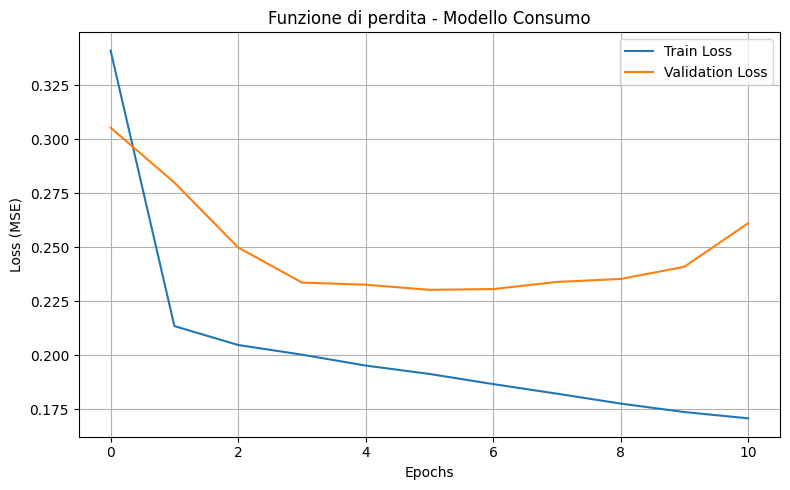

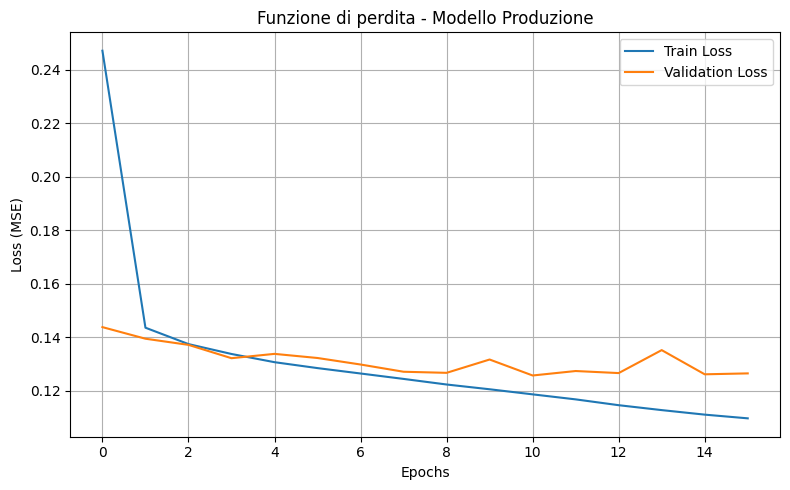

In [29]:
# <cell 59>
# Calcolo e visualizzazione delle Loss Function sui dataset TRAIN e VAL (Consumo e Produzione)
def plot_loss(history, title):
    plt.figure(figsize=(8,5))
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(title)
    plt.xlabel('Epochs')
    plt.ylabel('Loss (MSE)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Plot per modello consumo
plot_loss(history_cons, "Funzione di perdita - Modello Consumo")

# Plot per modello produzione
plot_loss(history_prod, "Funzione di perdita - Modello Produzione")

### Visualizza Grafico comparativo tra Consumo Reale e Predetto (finestra)

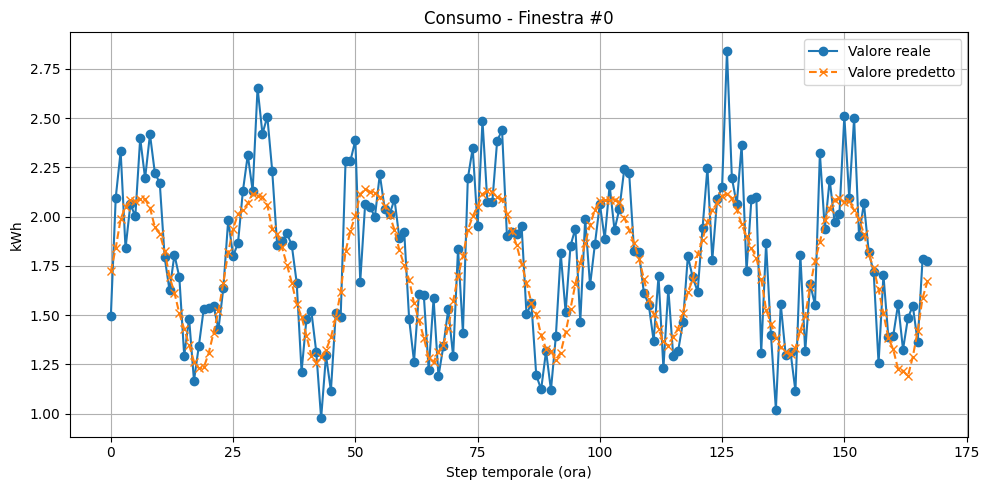

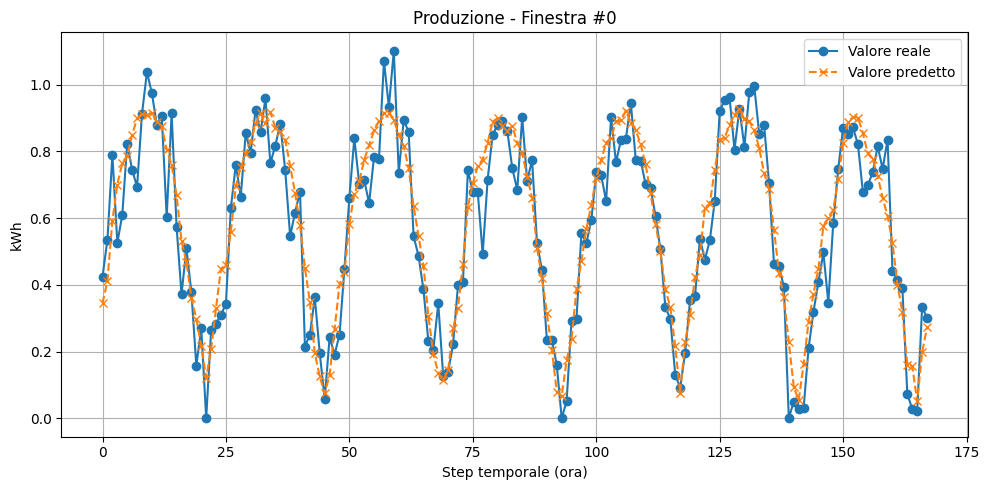

In [30]:
# <cell 61>
# Visualizza Grafico comparativo tra Consumo Reale e Predetto (finestra)
def plot_confronto_window(y_true, y_pred, window_idx=0, title_prefix=""):
    if window_idx >= len(y_true):
        print("❌ Errore: indice fuori range.")
        return

    true_vals = y_true[window_idx].flatten()
    pred_vals = y_pred[window_idx].flatten()

    plt.figure(figsize=(10, 5))
    plt.plot(true_vals, label='Valore reale', marker='o', linestyle='-')
    plt.plot(pred_vals, label='Valore predetto', marker='x', linestyle='--')
    plt.title(f"{title_prefix} - Finestra #{window_idx}")
    plt.xlabel("Step temporale (ora)")
    plt.ylabel("kWh")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

#OLD-COD-INI
# plot_confronto_window(y_test_c, y_pred_test_c, window_idx=0, title_prefix="Consumo")
# plot_confronto_window(y_test_p, y_pred_test_p, window_idx=0, title_prefix="Produzione")
#OLD-COD-FIN
#
# NEW-COD-INI
# I grafici comparativi devono usare la scala fisica originale, non la scala normalizzata.
plot_confronto_window(y_test_c_orig, y_pred_test_c_orig, window_idx=0, title_prefix="Consumo")
plot_confronto_window(y_test_p_orig, y_pred_test_p_orig, window_idx=0, title_prefix="Produzione")
#
#NEW-COD-FIN

### Visualizza Grafico comparativo tra Consumo Reale e Predetto (intero periodo di analisi)

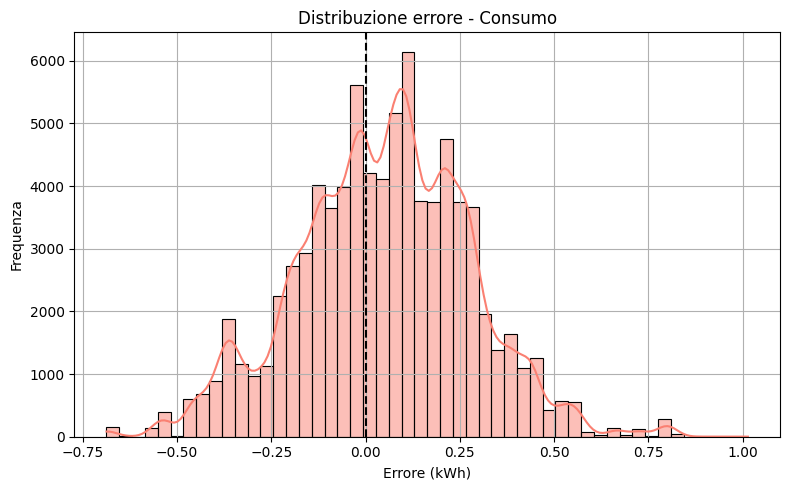

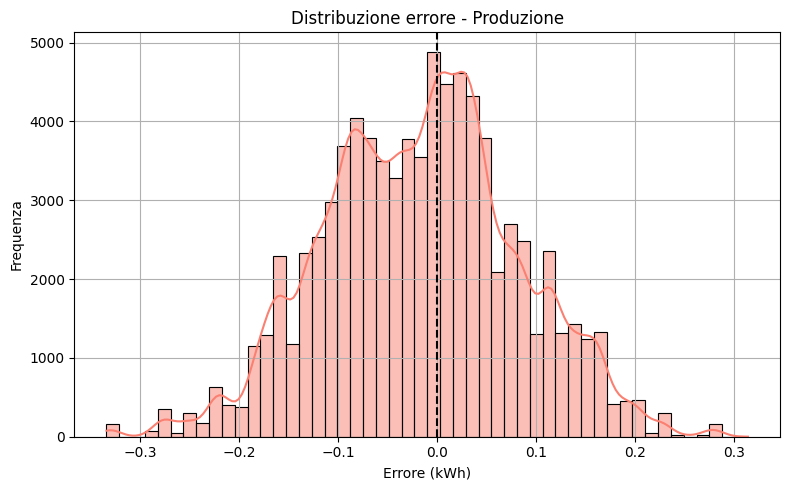

In [31]:
# <cell 63>
# Visualizza Grafico comparativo tra Consumo Reale e Predetto (intero periodo di analisi)
def plot_error_distribution(y_true, y_pred, title="Distribuzione errore", bins=50):
    errors = y_true.flatten() - y_pred.flatten()

    plt.figure(figsize=(8, 5))
    sns.histplot(errors, bins=bins, kde=True, color='salmon')
    plt.axvline(0, color='black', linestyle='--')
    plt.title(title)
    plt.xlabel("Errore (kWh)")
    plt.ylabel("Frequenza")
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
#OLD-COD-INI
# plot_error_distribution(y_test_c, y_pred_test_c, title="Distribuzione errore - Consumo")
# plot_error_distribution(y_test_p, y_pred_test_p, title="Distribuzione errore - Produzione")
#OLD-COD-FIN
#
#NEW-COD-INI
# Distribuzione errori in unità originali per mantenere interpretabilità fisica delle metriche.
plot_error_distribution(y_test_c_orig, y_pred_test_c_orig, title="Distribuzione errore - Consumo")
plot_error_distribution(y_test_p_orig, y_pred_test_p_orig, title="Distribuzione errore - Produzione")
#NEW-COD-FIN

### 8. Previsione sui prossimi 7 giorni (placeholder esemplificativo)

In [32]:
# <cell 65>
print("Esecuzione previsione sui prossimi 7 giorni...")

# Setup logging
log_dir = Path('logs')
log_dir.mkdir(exist_ok=True)
log_filename = log_dir / f"forecast_{dt.now().strftime('%Y%m%d_%H%M%S')}.log"
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s', handlers=[logging.FileHandler(log_filename), logging.StreamHandler()])
logger = logging.getLogger(__name__)

try:
    # --- Previsione consumo ---
    X_enc_future = df_features_past_cons_scaled.iloc[-PAST_WINDOW:].values.reshape(1, PAST_WINDOW, n_features_enc)
    X_dec_future_raw = meteo_future[['temperature', 'irradiance', 'wind_speed']].values
    X_dec_future_scaled = scaler_features_cons.transform(
        np.hstack([X_dec_future_raw, np.zeros((X_dec_future_raw.shape[0], 1))])
    )[:, :3].reshape(1, FUTURE_WINDOW, n_features_dec)

    logger.info(f"Encoder future shape: {X_enc_future.shape}")
    logger.info(f"Decoder future shape: {X_dec_future_scaled.shape}")

    y_pred_future_scaled = model_cons.predict([X_enc_future, X_dec_future_scaled], verbose=0)
    y_pred_future = inverse_transform_array(y_pred_future_scaled, scaler_cons_target).flatten()

    # --- Previsione produzione ---
    X_enc_future_prod = df_features_past_prod_scaled.iloc[-PAST_WINDOW:].values.reshape(1, PAST_WINDOW, n_features_enc_p)
    X_dec_future_prod_raw = meteo_future[['temperature', 'irradiance', 'wind_speed']].values
    X_dec_future_prod = scaler_features_prod.transform(
        np.hstack([X_dec_future_prod_raw, np.zeros((X_dec_future_prod_raw.shape[0], 1))])
    )[:, :3].reshape(1, FUTURE_WINDOW, n_features_dec_p)

    y_pred_production_scaled = model_prod.predict([X_enc_future_prod, X_dec_future_prod], verbose=0)
    y_pred_production = inverse_transform_array(y_pred_production_scaled, scaler_prod_target).flatten()

    # --- Costruzione DataFrame forecast ---
    df_forecast = pd.DataFrame({
        'timestamp': idx_future,
        'forecasted_consumption': y_pred_future,
        'forecasted_production': y_pred_production
    }).set_index('timestamp')

    df_forecast["bilancio"] = df_forecast["forecasted_production"] - df_forecast["forecasted_consumption"]
    df_forecast["etichetta"] = df_forecast["bilancio"].apply(lambda x: "rilascio" if x > 0 else "acquisto")

    df_forecast.to_csv("bilancio_energetico.csv")

    print("Previsioni completate. Ecco le prime righe:")
    print(df_forecast.head())

except Exception as e:
    logger.exception("Errore durante la previsione")
    print("❌ Errore durante la previsione:", type(e).__name__, "-", e)

2026-04-09 12:02:14,649 - INFO - Encoder future shape: (1, 168, 4)
2026-04-09 12:02:14,656 - INFO - Decoder future shape: (1, 168, 3)


Esecuzione previsione sui prossimi 7 giorni...
Previsioni completate. Ecco le prime righe:
                           forecasted_consumption  forecasted_production  \
timestamp                                                                  
2026-04-09 12:00:00+02:00                1.790813               0.904740   
2026-04-09 13:00:00+02:00                1.722653               0.881152   
2026-04-09 14:00:00+02:00                1.668561               0.840754   
2026-04-09 15:00:00+02:00                1.621622               0.810191   
2026-04-09 16:00:00+02:00                1.540311               0.792305   

                           bilancio etichetta  
timestamp                                      
2026-04-09 12:00:00+02:00 -0.886072  acquisto  
2026-04-09 13:00:00+02:00 -0.841501  acquisto  
2026-04-09 14:00:00+02:00 -0.827807  acquisto  
2026-04-09 15:00:00+02:00 -0.811431  acquisto  
2026-04-09 16:00:00+02:00 -0.748007  acquisto  


### 9. Calcolo differenza e report

In [33]:
# <cell 67>
# 9. Calcolo differenza e report
print("Calcolo differenza tra consumo e produzione e generazione report...")

try:
    # --- Calcolo bilancio energetico ---
    df_forecast['net_balance'] = df_forecast['forecasted_production'] - df_forecast['forecasted_consumption']
    df_forecast['to_grid'] = df_forecast['net_balance'].apply(lambda x: x if x > 0 else 0)
    df_forecast['to_buy'] = df_forecast['net_balance'].apply(lambda x: -x if x < 0 else 0)

    # --- Report sintetico ---
    print("Bilancio energetico calcolato. Ecco un riepilogo:")
    print(df_forecast[['forecasted_consumption', 'forecasted_production', 'to_grid', 'to_buy']].head())

    print("\n📊 Riepilogo energia per i prossimi 7 giorni:")
    print("Energia da immettere in rete [kWh]:", round(df_forecast['to_grid'].sum(), 2))
    print("Energia da acquistare [kWh]:", round(df_forecast['to_buy'].sum(), 2))

except Exception as e:
    print("❌ Errore durante il calcolo del bilancio:", type(e).__name__, "-", e)

Calcolo differenza tra consumo e produzione e generazione report...
Bilancio energetico calcolato. Ecco un riepilogo:
                           forecasted_consumption  forecasted_production  \
timestamp                                                                  
2026-04-09 12:00:00+02:00                1.790813               0.904740   
2026-04-09 13:00:00+02:00                1.722653               0.881152   
2026-04-09 14:00:00+02:00                1.668561               0.840754   
2026-04-09 15:00:00+02:00                1.621622               0.810191   
2026-04-09 16:00:00+02:00                1.540311               0.792305   

                           to_grid    to_buy  
timestamp                                     
2026-04-09 12:00:00+02:00        0  0.886072  
2026-04-09 13:00:00+02:00        0  0.841501  
2026-04-09 14:00:00+02:00        0  0.827807  
2026-04-09 15:00:00+02:00        0  0.811431  
2026-04-09 16:00:00+02:00        0  0.748007  

📊 Riepilogo energia

### 10. Grafici riepilogativi

#### 1. Produzione e consumo previsti

Generazione grafici riepilogativi...


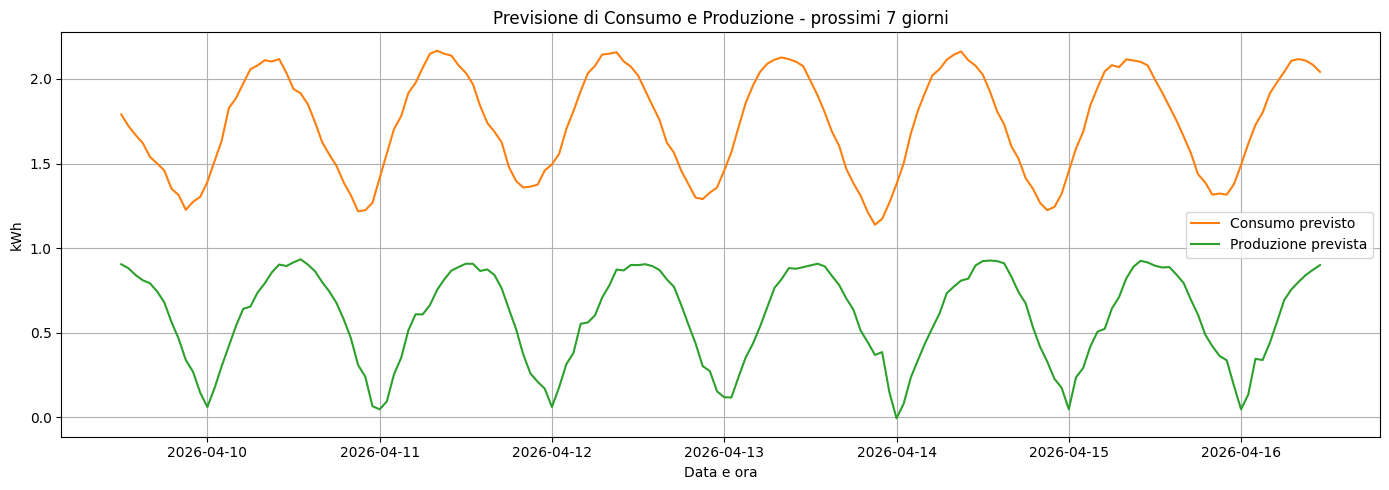

In [34]:
# <cell 70>
# 1. Produzione e consumo previsti
print("Generazione grafici riepilogativi...")

import matplotlib.dates as mdates

# 1. Produzione e consumo previsti
plt.figure(figsize=(14, 5))
plt.plot(df_forecast.index, df_forecast['forecasted_consumption'], label='Consumo previsto', color='tab:orange')
plt.plot(df_forecast.index, df_forecast['forecasted_production'], label='Produzione prevista', color='tab:green')
plt.title('Previsione di Consumo e Produzione - prossimi 7 giorni')
plt.xlabel('Data e ora')
plt.ylabel('kWh')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#### 2. Energia da acquistare o cedere (differenza oraria)

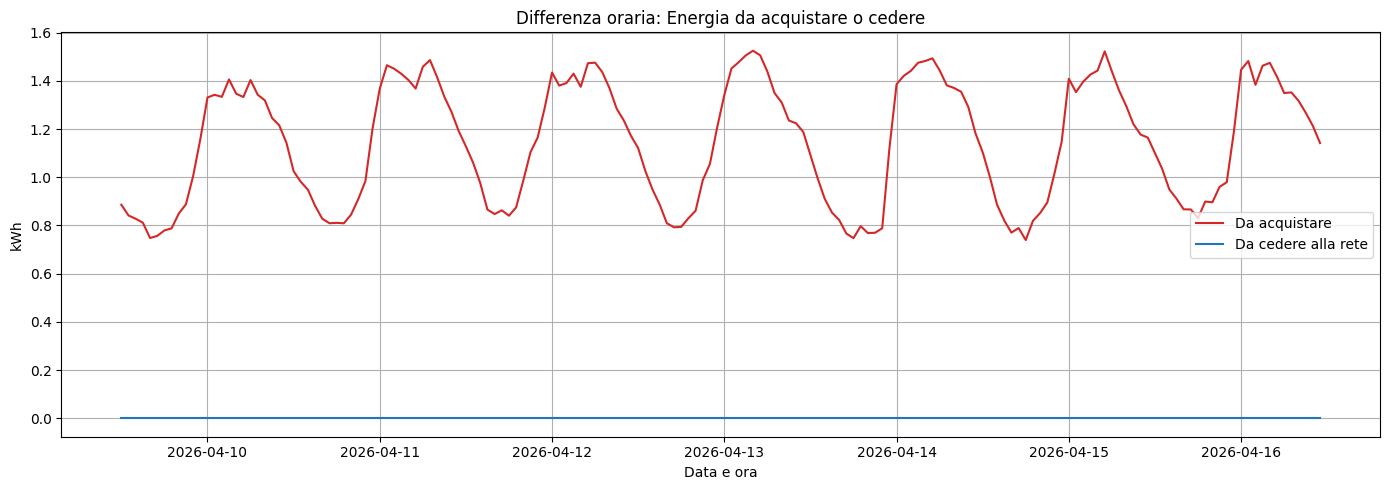

In [35]:
# <cell 72>
# 2. Energia da acquistare o cedere (differenza oraria)
plt.figure(figsize=(14, 5))
plt.plot(df_forecast.index, df_forecast['to_buy'], label='Da acquistare', color='tab:red')
plt.plot(df_forecast.index, df_forecast['to_grid'], label='Da cedere alla rete', color='tab:blue')
plt.title('Differenza oraria: Energia da acquistare o cedere')
plt.xlabel('Data e ora')
plt.ylabel('kWh')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#### 3. Grafico cumulativo

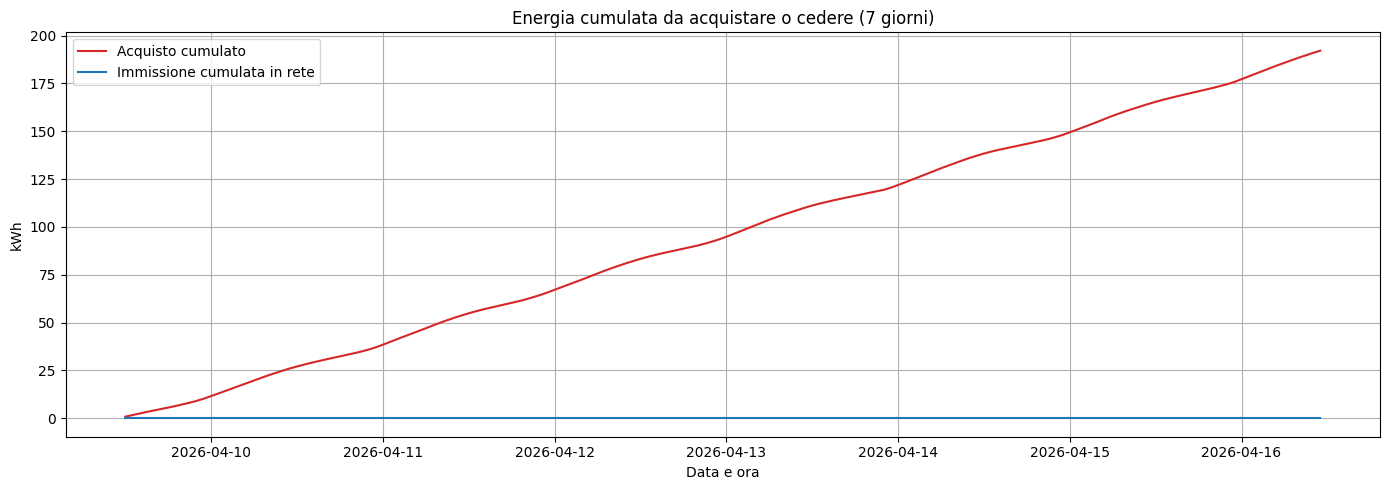

In [36]:
# <cell 74>
# 3. Grafico cumulativo
df_forecast['cumulative_buy'] = df_forecast['to_buy'].cumsum()
df_forecast['cumulative_grid'] = df_forecast['to_grid'].cumsum()

plt.figure(figsize=(14, 5))
plt.plot(df_forecast.index, df_forecast['cumulative_buy'], label='Acquisto cumulato', color='tab:red')
plt.plot(df_forecast.index, df_forecast['cumulative_grid'], label='Immissione cumulata in rete', color='tab:blue')
plt.title('Energia cumulata da acquistare o cedere (7 giorni)')
plt.xlabel('Data e ora')
plt.ylabel('kWh')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()